**Configuration note:** this notebook analyzes paralog RNA-seq expression. It reads `paralog_families_counts.tsv` (featureCounts / Salmon TPM) and `paralog_families.tsv` (family metadata from `build_paralog_families.py`) from the working directory. Inputs mirror `config.sh` at the repo root.


# Paralog RNA-seq Support Analysis
---
**Purpose**: Systematically quantify RNA-seq read support for all 1,147 paralog families 
to distinguish true paralogs from potential allelic duplicates.

**Inputs**:
- `paralog_families_counts.tsv` — featureCounts output (gene-level counts across 29 tissue samples)
- `paralog_families.tsv` — gene family metadata (family, gene_name, type, coordinates, length)
- Tissue metadata from the existing notebook

**Outputs**:
- `paralog_support_summary.tsv` — per-paralog classification table
- `paralog_support_families.tsv` — per-family summary with parent comparison
- Figures for publication

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## 1. Load and prepare data

In [6]:
# Tissue metadata — from the existing notebook (29 samples, 6 tissues)
sample_tissue = {
    'SRR17216293': 'skin',    'SRR17216294': 'brain',   'SRR17216295': 'heart',
    'SRR17216296': 'kidney',  'SRR17216297': 'liver',   'SRR17216298': 'lung',
    'SRR17216299': 'skin',    'SRR17216300': 'brain',   'SRR17216301': 'heart',
    'SRR17216302': 'kidney',  'SRR17216303': 'liver',   'SRR17216304': 'lung',
    'SRR17216305': 'skin',    'SRR17216306': 'brain',   'SRR17216307': 'heart',
    'SRR17216308': 'kidney',  'SRR17216309': 'liver',   'SRR17216310': 'lung',
    'SRR17216311': 'brain',   'SRR17216312': 'heart',   'SRR17216313': 'kidney',
    'SRR17216314': 'kidney',  'SRR17216315': 'lung',    'SRR17216316': 'skin',
    'SRR17216317': 'heart',   'SRR17216318': 'kidney',  'SRR17216319': 'liver',
    'SRR17216320': 'brain',   'SRR17216321': 'lung'
}
tissues = ['skin', 'brain', 'heart', 'kidney', 'liver', 'lung']
tissue_colors = {
    'skin': '#E8A87C', 'brain': '#C38D9E', 'heart': '#E27D60',
    'kidney': '#85CDCA', 'liver': '#E8A87C', 'lung': '#41B3A3'
}

print(f'Samples: {len(sample_tissue)}, Tissues: {len(tissues)}')

Samples: 29, Tissues: 6


In [7]:
# Load featureCounts output
counts_raw = pd.read_csv('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families_counts.tsv', sep='\t', comment='#', index_col=0)
print(f'Counts shape: {counts_raw.shape}')
print(f'Columns: {list(counts_raw.columns[:8])}...')

# Separate annotation columns from count columns
anno_cols = ['Chr', 'Start', 'End', 'Strand', 'Length']
sample_cols = [c for c in counts_raw.columns if c.startswith('SRR')]

print(f'Annotation columns: {anno_cols}')
print(f'Sample columns: {len(sample_cols)}')

# Extract counts matrix (samples x genes)
counts = counts_raw[sample_cols].copy()
gene_info = counts_raw[anno_cols].copy()

# Clean sample names (remove .bam suffix)
counts.columns = [c.replace('_Aligned.sortedByCoord.out.bam', '') for c in counts.columns]

counts.head()

Counts shape: (3272, 34)
Columns: ['Chr', 'Start', 'End', 'Strand', 'Length', 'SRR17216293_Aligned.sortedByCoord.out.bam', 'SRR17216294_Aligned.sortedByCoord.out.bam', 'SRR17216295_Aligned.sortedByCoord.out.bam']...
Annotation columns: ['Chr', 'Start', 'End', 'Strand', 'Length']
Sample columns: 29


,SRR17216293,SRR17216294,SRR17216295,SRR17216296,SRR17216297,SRR17216298,SRR17216299,SRR17216300,SRR17216301,SRR17216302,...,SRR17216312,SRR17216313,SRR17216314,SRR17216315,SRR17216316,SRR17216317,SRR17216318,SRR17216319,SRR17216320,SRR17216321
Geneid,,,,,,,,,,,,,,,,,,,,,
gene-Aadac,14,1,203,14344,17902,9,22,4,0,9338,...,2,7968,15947,105,16,12,11555,13138,4,32
gene-Aadac-l1,1053,2,80,392,5309,20,707,6,12,279,...,14,234,5662,347,236,8,391,2149,2,135
gene-Aadac-l2,854,0,4,15,4,0,839,0,0,6,...,0,1,12,6,174,0,0,1,0,1
gene-Aadac-l3,104,27,215,168,2309,77,195,46,221,117,...,240,88,5029,871,32,178,76,1847,40,151
gene-Aadacl4,190,0,0,0,0,0,301,0,0,0,...,0,1,0,2,20,0,0,0,1,0


In [8]:
# Load gene family metadata
families_df = pd.read_csv('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/paralog-alignment-visualization/paralog_families.tsv', sep='\t')
print(f'Family metadata: {families_df.shape[0]} genes in {families_df["family"].nunique()} families')
print(f'\nGene types:')
print(families_df['gene_type'].value_counts())
print(f'\nParalog types:')
print(families_df['paralog_type'].value_counts(dropna=False))

# Merge gene metadata with counts
# Use gene_id (from GFF) to match — featureCounts uses the ID= field from the GFF
families_df_indexed = families_df.set_index('gene_id')

# Check overlap
common_ids = set(counts.index) & set(families_df_indexed.index)
print(f'\nGene IDs in both counts and metadata: {len(common_ids)} / {len(counts.index)}')

# Merge
meta_cols_merge = ['family', 'gene_name', 'gene_type', 'paralog_type', 'copy_num', 'length']
counts_merged = counts.join(families_df_indexed[meta_cols_merge], how='left')

# Use the metadata length for TPM (more reliable than featureCounts Length column)
counts_merged['gene_length'] = counts_merged['length'].fillna(counts_raw['Length'])

print(f'\nMerged counts: {counts_merged.shape}')
counts_merged[['family', 'gene_name', 'gene_type', 'gene_length']].head(10)

Family metadata: 3272 genes in 1091 families

Gene types:
gene_type
paralog_dl    1202
parent        1091
paralog_l      972
paralog_rl       7
Name: count, dtype: int64

Paralog types:
paralog_type
dl     1202
NaN    1091
l       972
rl        7
Name: count, dtype: int64

Gene IDs in both counts and metadata: 3272 / 3272

Merged counts: (3272, 36)


,family,gene_name,gene_type,gene_length
Geneid,,,,
gene-Aadac,Aadac,Aadac,parent,20944
gene-Aadac-l1,Aadac,Aadac-l1,paralog_l,18517
gene-Aadac-l2,Aadac,Aadac-l2,paralog_l,13583
gene-Aadac-l3,Aadac,Aadac-l3,paralog_l,12941
gene-Aadacl4,Aadacl4,Aadacl4,parent,24069
gene-Aadacl4-l1,Aadacl4,Aadacl4-l1,paralog_l,11569
gene-Aadacl4-l2,Aadacl4,Aadacl4-l2,paralog_l,17471
gene-Aadacl4-l3,Aadacl4,Aadacl4-l3,paralog_l,21443
gene-Aasdhppt,Aasdhppt,Aasdhppt,parent,29969


## 2. TPM normalization

In [9]:
def calculate_tpm(counts_df, gene_lengths, sample_cols_list):
    """Calculate TPM from raw counts and gene lengths."""
    # RPK: reads per kilobase
    rpk = counts_df[sample_cols_list].div(gene_lengths / 1000, axis=0)
    # TPM: RPK / sum(RPK) * 1e6
    tpm = rpk.div(rpk.sum(axis=0), axis=1) * 1e6
    return tpm

# Calculate TPM
sample_list = list(counts.columns)
tpm = calculate_tpm(counts_merged, counts_merged['gene_length'], sample_list)

# Attach metadata
tpm_full = tpm.copy()
tpm_full['family'] = counts_merged['family']
tpm_full['gene_name'] = counts_merged['gene_name']
tpm_full['gene_type'] = counts_merged['gene_type']
tpm_full['gene_length'] = counts_merged['gene_length']
tpm_full['paralog_type'] = counts_merged['paralog_type']

print(f'TPM matrix: {tpm_full.shape}')
print(f'\nTPM distribution (all genes):')
tpm_vals = tpm.values.flatten()
tpm_vals = tpm_vals[tpm_vals > 0]
print(f'  Non-zero entries: {len(tpm_vals):,} / {tpm.size:,} ({100*len(tpm_vals)/tpm.size:.1f}%)')
print(f'  Median (non-zero): {np.median(tpm_vals):.2f}')
print(f'  Mean (non-zero):   {np.mean(tpm_vals):.2f}')
print(f'  Max:               {np.max(tpm_vals):.2f}')

# Quick sanity check
print(f'\nTPM sum per sample (should be ~1e6):')
for s in sample_list[:5]:
    print(f'  {s}: {tpm[s].sum():,.0f}')

TPM matrix: (3272, 34)

TPM distribution (all genes):
  Non-zero entries: 76,356 / 94,888 (80.5%)
  Median (non-zero): 68.89
  Mean (non-zero):   379.80
  Max:               47635.15

TPM sum per sample (should be ~1e6):
  SRR17216293: 1,000,000
  SRR17216294: 1,000,000
  SRR17216295: 1,000,000
  SRR17216296: 1,000,000
  SRR17216297: 1,000,000


## 3. Per-gene expression metrics

In [10]:
def compute_gene_metrics(counts_df, tpm_df, sample_list, sample_tissue_dict, tissues_list):
    """Compute per-gene expression metrics."""
    metrics = pd.DataFrame(index=counts_df.index)
    
    # Detection: % samples with > 0 counts
    metrics['n_samples_detected'] = (counts_df[sample_list] > 0).sum(axis=1)
    metrics['pct_samples_detected'] = 100 * metrics['n_samples_detected'] / len(sample_list)
    
    # Detection by tissue (at least 1 replicate > 0)
    for tissue in tissues_list:
        tissue_samples = [s for s, t in sample_tissue_dict.items() if t == tissue]
        n_detected = (counts_df[tissue_samples] > 0).sum(axis=1)
        metrics[f'n_reps_{tissue}'] = n_detected
        metrics[f'detected_{tissue}'] = (n_detected > 0).astype(int)
    metrics['n_tissues_detected'] = metrics[[f'detected_{t}' for t in tissues_list]].sum(axis=1)
    
    # Expression levels
    metrics['mean_count'] = counts_df[sample_list].mean(axis=1)
    metrics['max_count'] = counts_df[sample_list].max(axis=1)
    metrics['total_count'] = counts_df[sample_list].sum(axis=1)
    metrics['mean_tpm'] = tpm_df[sample_list].mean(axis=1)
    metrics['max_tpm'] = tpm_df[sample_list].max(axis=1)
    
    # Tissue-specific mean TPM
    for tissue in tissues_list:
        tissue_samples = [s for s, t in sample_tissue_dict.items() if t == tissue]
        metrics[f'mean_tpm_{tissue}'] = tpm_df[tissue_samples].mean(axis=1)
    
    # Expression breadth: entropy-based tissue specificity
    # Low entropy = tissue-specific; high entropy = broadly expressed
    tissue_tpm = pd.DataFrame({t: tpm_df[[s for s, tm in sample_tissue_dict.items() if tm == t]].mean(axis=1)
                               for t in tissues_list})
    tissue_fraction = tissue_tpm.div(tissue_tpm.sum(axis=1), axis=0).fillna(0)
    entropy = -(tissue_fraction * np.log2(tissue_fraction + 1e-10)).sum(axis=1)
    metrics['tissue_specificity'] = 1 - (entropy / np.log2(len(tissues_list)))  # 0=broad, 1=specific
    
    return metrics

gene_metrics = compute_gene_metrics(counts_merged, tpm_full, sample_list, sample_tissue, tissues)

# Merge with metadata
gene_metrics['family'] = counts_merged['family']
gene_metrics['gene_name'] = counts_merged['gene_name']
gene_metrics['gene_type'] = counts_merged['gene_type']
gene_metrics['paralog_type'] = counts_merged['paralog_type']
gene_metrics['gene_length'] = counts_merged['gene_length']

print(f'Gene metrics computed for {len(gene_metrics)} genes')
gene_metrics.head()

Gene metrics computed for 3272 genes


,n_samples_detected,pct_samples_detected,n_reps_skin,detected_skin,n_reps_brain,detected_brain,n_reps_heart,detected_heart,n_reps_kidney,detected_kidney,...,mean_tpm_heart,mean_tpm_kidney,mean_tpm_liver,mean_tpm_lung,tissue_specificity,family,gene_name,gene_type,paralog_type,gene_length
Geneid,,,,,,,,,,,,,,,,,,,,,
gene-Aadac,28,96.551724,4,1,5,1,4,1,6,1,...,1.453682,599.796223,703.287072,3.703231,0.591828,Aadac,Aadac,parent,NaN,20944
gene-Aadac-l1,29,100.000000,4,1,5,1,5,1,6,1,...,1.044310,59.028281,182.902040,13.630369,0.362308,Aadac,Aadac-l1,paralog_l,l,18517
gene-Aadac-l2,18,62.068966,4,1,0,0,1,1,5,1,...,0.040415,0.315404,0.166968,0.348145,0.967060,Aadac,Aadac-l2,paralog_l,l,13583
gene-Aadac-l3,29,100.000000,4,1,5,1,5,1,6,1,...,10.905904,61.676265,157.581429,46.355654,0.279884,Aadac,Aadac-l3,paralog_l,l,12941
gene-Aadacl4,8,27.586207,4,1,2,1,0,0,1,1,...,0.000000,0.016270,0.000000,0.010345,0.985730,Aadacl4,Aadacl4,parent,NaN,24069


## 4. Per-family analysis: parent-paralog comparison

In [11]:
def analyze_family(family_name, tpm_df, metrics_df, sample_list, sample_tissue_dict, tissues_list):
    """
    For one gene family, compare parent vs paralogs.
    Returns a dict of family-level metrics.
    """
    fam_genes = tpm_df[tpm_df['family'] == family_name]
    fam_metrics = metrics_df[metrics_df['family'] == family_name]
    
    parent = fam_genes[fam_genes['gene_type'] == 'parent']
    paralogs = fam_genes[fam_genes['gene_type'] != 'parent']
    
    result = {
        'family': family_name,
        'has_parent': len(parent) > 0,
        'n_paralogs': len(paralogs),
        'n_paralogs_l': (paralogs['paralog_type'] == 'l').sum(),
        'n_paralogs_dl': (paralogs['paralog_type'] == 'dl').sum(),
        'n_paralogs_rl': (paralogs['paralog_type'] == 'rl').sum(),
    }
    
    # Parent metrics
    if len(parent) > 0:
        p_metrics = fam_metrics.loc[parent.index[0]]
        result['parent_mean_tpm'] = p_metrics['mean_tpm']
        result['parent_max_tpm'] = p_metrics['max_tpm']
        result['parent_n_tissues'] = p_metrics['n_tissues_detected']
        result['parent_detected'] = p_metrics['n_samples_detected'] > 0
        
        # Parent expression vector across tissues (mean per tissue)
        parent_tissue_tpm = np.array([
            tpm_df.loc[parent.index[0], [s for s, tm in sample_tissue_dict.items() if tm == t]].mean()
            for t in tissues_list
        ])
    else:
        result['parent_mean_tpm'] = 0
        result['parent_max_tpm'] = 0
        result['parent_n_tissues'] = 0
        result['parent_detected'] = False
        parent_tissue_tpm = np.zeros(len(tissues_list))
    
    # Per-paralog metrics and correlations
    paralog_results = []
    for idx, row in paralogs.iterrows():
        p_metrics = fam_metrics.loc[idx]
        
        # Expression vector across tissues
        paralog_tissue_tpm = np.array([
            tpm_df.loc[idx, [s for s, tm in sample_tissue_dict.items() if tm == t]].mean()
            for t in tissues_list
        ])
        
        # Correlation with parent (if parent has expression)
        if result['parent_detected'] and parent_tissue_tpm.sum() > 0:
            # Pearson on log-transformed TPM to handle scale differences
            with np.errstate(invalid='ignore'):
                log_parent = np.log2(parent_tissue_tpm + 0.1)
                log_para = np.log2(paralog_tissue_tpm + 0.1)
                if np.std(log_para) > 0 and np.std(log_parent) > 0:
                    r, pval = pearsonr(log_parent, log_para)
                else:
                    r, pval = np.nan, np.nan
        else:
            r, pval = np.nan, np.nan
        
        paralog_results.append({
            'gene_name': row['gene_name'],
            'paralog_type': row['paralog_type'],
            'mean_tpm': p_metrics['mean_tpm'],
            'max_tpm': p_metrics['max_tpm'],
            'n_tissues_detected': p_metrics['n_tissues_detected'],
            'n_samples_detected': p_metrics['n_samples_detected'],
            'detected': p_metrics['n_samples_detected'] > 0,
            'corr_with_parent': r,
            'corr_pvalue': pval,
            'tissue_specificity': p_metrics['tissue_specificity'],
        })
    
    result['paralogs'] = paralog_results
    
    # Summary stats across paralogs
    if paralog_results:
        result['n_paralogs_detected'] = sum(1 for p in paralog_results if p['detected'])
        result['mean_paralog_tpm'] = np.mean([p['mean_tpm'] for p in paralog_results])
        result['max_paralog_tpm'] = np.max([p['max_tpm'] for p in paralog_results])
        
        # TPM ratio: total paralog TPM / parent TPM
        total_paralog_tpm = sum(p['mean_tpm'] for p in paralog_results)
        if result['parent_mean_tpm'] > 0:
            result['paralog_parent_tpm_ratio'] = total_paralog_tpm / result['parent_mean_tpm']
        else:
            result['paralog_parent_tpm_ratio'] = np.inf if total_paralog_tpm > 0 else np.nan
        
        # How many paralogs highly correlated with parent? (potential alleles)
        correlated = [p for p in paralog_results 
                      if p['corr_with_parent'] is not None 
                      and not np.isnan(p['corr_with_parent'])
                      and p['corr_with_parent'] > 0.8]
        result['n_parent correlated'] = len(correlated)
    else:
        result['n_paralogs_detected'] = 0
        result['mean_paralog_tpm'] = 0
        result['max_paralog_tpm'] = 0
        result['paralog_parent_tpm_ratio'] = np.nan
        result['n_parent correlated'] = 0
    
    return result

# Analyze all families
all_families = sorted(tpm_full['family'].unique())
family_results = []
all_paralog_results = []

for fam in all_families:
    res = analyze_family(fam, tpm_full, gene_metrics, sample_list, sample_tissue, tissues)
    family_results.append(res)
    for p in res['paralogs']:
        p['family'] = fam
        all_paralog_results.append(p)

paralog_df = pd.DataFrame(all_paralog_results)
print(f'Analyzed {len(family_results)} families, {len(paralog_df)} paralogs')

# Family-level summary DataFrame
family_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'paralogs'}
    for r in family_results
])
print(f'Family summary: {family_summary.shape}')
family_summary.head()

Analyzed 1091 families, 2181 paralogs
Family summary: (1091, 15)


,family,has_parent,n_paralogs,n_paralogs_l,n_paralogs_dl,n_paralogs_rl,parent_mean_tpm,parent_max_tpm,parent_n_tissues,parent_detected,n_paralogs_detected,mean_paralog_tpm,max_paralog_tpm,paralog_parent_tpm_ratio,n_parent correlated
0,Aadac,True,3,3,0,0,222.438736,1009.113169,6,True,3,38.187532,324.323819,0.515030,1
1,Aadacl4,True,3,3,0,0,1.905100,27.977681,4,True,3,8.206529,233.991456,12.922991,2
2,Aasdhppt,True,1,1,0,0,112.534108,337.649723,6,True,1,275.885876,1007.705620,2.451576,1
3,Abca3,True,1,1,0,0,135.587494,781.584124,6,True,1,6.841103,18.635304,0.050455,0
4,Abcb1,True,1,1,0,0,14.041412,21.982843,6,True,1,13.397052,55.053102,0.954110,0


## 5. Classification of paralogs

In [12]:
def classify_paralog(row, parent_has_expression=True, parent_comparison_possible=True):
    """
    Classify a paralog based on expression evidence.
    
    Categories:
      - 'supported': strong independent expression, parent exists and is expressed
      - 'robust expression': strong expression but no parent comparison possible
      - 'parent correlated': expressed but highly correlated with parent
      - 'low expression': detectable but weak
      - 'unsupported': no RNA-seq evidence
    """
    detected = row['n_samples_detected'] > 0
    multi_tissue = row['n_tissues_detected'] >= 2
    has_correlation = (not np.isnan(row.get('corr_with_parent', np.nan)) 
                       if 'corr_with_parent' in row else False)
    high_corr = has_correlation and row['corr_with_parent'] > 0.8
    moderate_expression = row['mean_tpm'] >= 0.5
    
    if not detected:
        return 'unsupported'
    
    if not multi_tissue or row['mean_tpm'] < 0.1:
        return 'low expression'
    
    if high_corr and parent_has_expression:
        # Highly correlated with parent — check if expression is substantial
        if row['mean_tpm'] >= 0.5:
            return 'parent correlated'  # TPM >= 0.5: real expression, parent-correlated
        else:
            return 'low expression'  # weak mirror of parent
    
    if moderate_expression and multi_tissue:
        if not parent_comparison_possible:
            return 'robust expression'  # good expression, but can't verify independence
        return 'supported'
    
    return 'low expression'

# Determine which families allow parent comparison
# Parent comparison is possible when: parent gene EXISTS AND parent IS DETECTED
families_with_parent_expr = set(
    family_summary[(family_summary['has_parent']) & (family_summary['parent_detected'])]['family']
)
print(f"Families with parent comparison possible: {len(families_with_parent_expr)} / {len(family_summary)}")

# Apply classification with parent-comparison awareness
paralog_df['classification'] = paralog_df.apply(
    lambda row: classify_paralog(
        row, 
        parent_has_expression=row['family'] in families_with_parent_expr,
        parent_comparison_possible=row['family'] in families_with_parent_expr
    ), axis=1
)

print("\n=== Paralogue classification ===")
print(paralog_df['classification'].value_counts())
print(f"\nTotal: {len(paralog_df)}")

# Breakdown by paralog type
print("\n=== By paralog type ===")
print(pd.crosstab(paralog_df['paralog_type'], paralog_df['classification'], margins=True))

# Quick summary of the robust expression category
robust = paralog_df[paralog_df['classification'] == 'robust expression']
print(f"\n=== Robust expression paralogs (no parent comparison): {len(robust)} ===")
print(f"  Mean TPM: {robust['mean_tpm'].median():.1f} (median), {robust['mean_tpm'].mean():.1f} (mean)")
print(f"  Tissues detected: {robust['n_tissues_detected'].median():.0f} (median)")
print(f"  By type: {dict(robust['paralog_type'].value_counts())}")

Families with parent comparison possible: 1064 / 1091

=== Paralogue classification ===
classification
supported            932
parent correlated    880
low expression       179
unsupported          169
robust expression     21
Name: count, dtype: int64

Total: 2181

=== By paralog type ===
classification  low expression  parent correlated  robust expression  \
paralog_type                                                           
dl                          59                549                 20   
l                          119                327                  1   
rl                           1                  4                  0   
All                        179                880                 21   

classification  supported  unsupported   All  
paralog_type                                  
dl                    520           54  1202  
l                     410          115   972  
rl                      2            0     7  
All                   932          169  

In [13]:
# ============================================================================
# Run pipeline: TPM -> per-gene metrics -> family analysis -> classification
# ============================================================================

# --- 1. TPM normalization ---
sample_list = list(counts.columns)
tpm = calculate_tpm(counts_merged, counts_merged['gene_length'], sample_list)

tpm_full = tpm.copy()
tpm_full['family'] = counts_merged['family']
tpm_full['gene_name'] = counts_merged['gene_name']
tpm_full['gene_type'] = counts_merged['gene_type']
tpm_full['gene_length'] = counts_merged['gene_length']
tpm_full['paralog_type'] = counts_merged['paralog_type']
print(f'TPM matrix: {tpm_full.shape}')

# --- 2. Per-gene expression metrics ---
gene_metrics = compute_gene_metrics(counts_merged, tpm_full, sample_list, sample_tissue, tissues)
gene_metrics['family'] = counts_merged['family']
gene_metrics['gene_name'] = counts_merged['gene_name']
gene_metrics['gene_type'] = counts_merged['gene_type']
gene_metrics['paralog_type'] = counts_merged['paralog_type']
gene_metrics['gene_length'] = counts_merged['gene_length']
print(f'Gene metrics computed for {len(gene_metrics)} genes')

# --- 3. Family analysis (parent-paralog comparison) ---
all_families = sorted(tpm_full['family'].unique())
family_results = []
all_paralog_results = []
for fam in all_families:
    res = analyze_family(fam, tpm_full, gene_metrics, sample_list, sample_tissue, tissues)
    family_results.append(res)
    for pr in res['paralogs']:
        pr['family'] = fam
        all_paralog_results.append(pr)

paralog_df = pd.DataFrame(all_paralog_results)
print(f'Analyzed {len(family_results)} families, {len(paralog_df)} paralogs')

family_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'paralogs'}
    for r in family_results
])
print(f'Family summary: {family_summary.shape}')

# --- 4. Classification ---
families_with_parent_expr = set(
    family_summary[(family_summary['has_parent']) & (family_summary['parent_detected'])]['family']
)
paralog_df['classification'] = paralog_df.apply(
    lambda row: classify_paralog(
        row,
        parent_has_expression=row['family'] in families_with_parent_expr,
        parent_comparison_possible=row['family'] in families_with_parent_expr,
    ), axis=1
)
print('\n=== Paralogue classification ===')
print(paralog_df['classification'].value_counts())


TPM matrix: (3272, 34)
Gene metrics computed for 3272 genes
Analyzed 1091 families, 2181 paralogs
Family summary: (1091, 15)

=== Paralogue classification ===
classification
supported            932
parent correlated    880
low expression       179
unsupported          169
robust expression     21
Name: count, dtype: int64


Total classified paralogs: 2,181
Rows with missing paralog type: 0


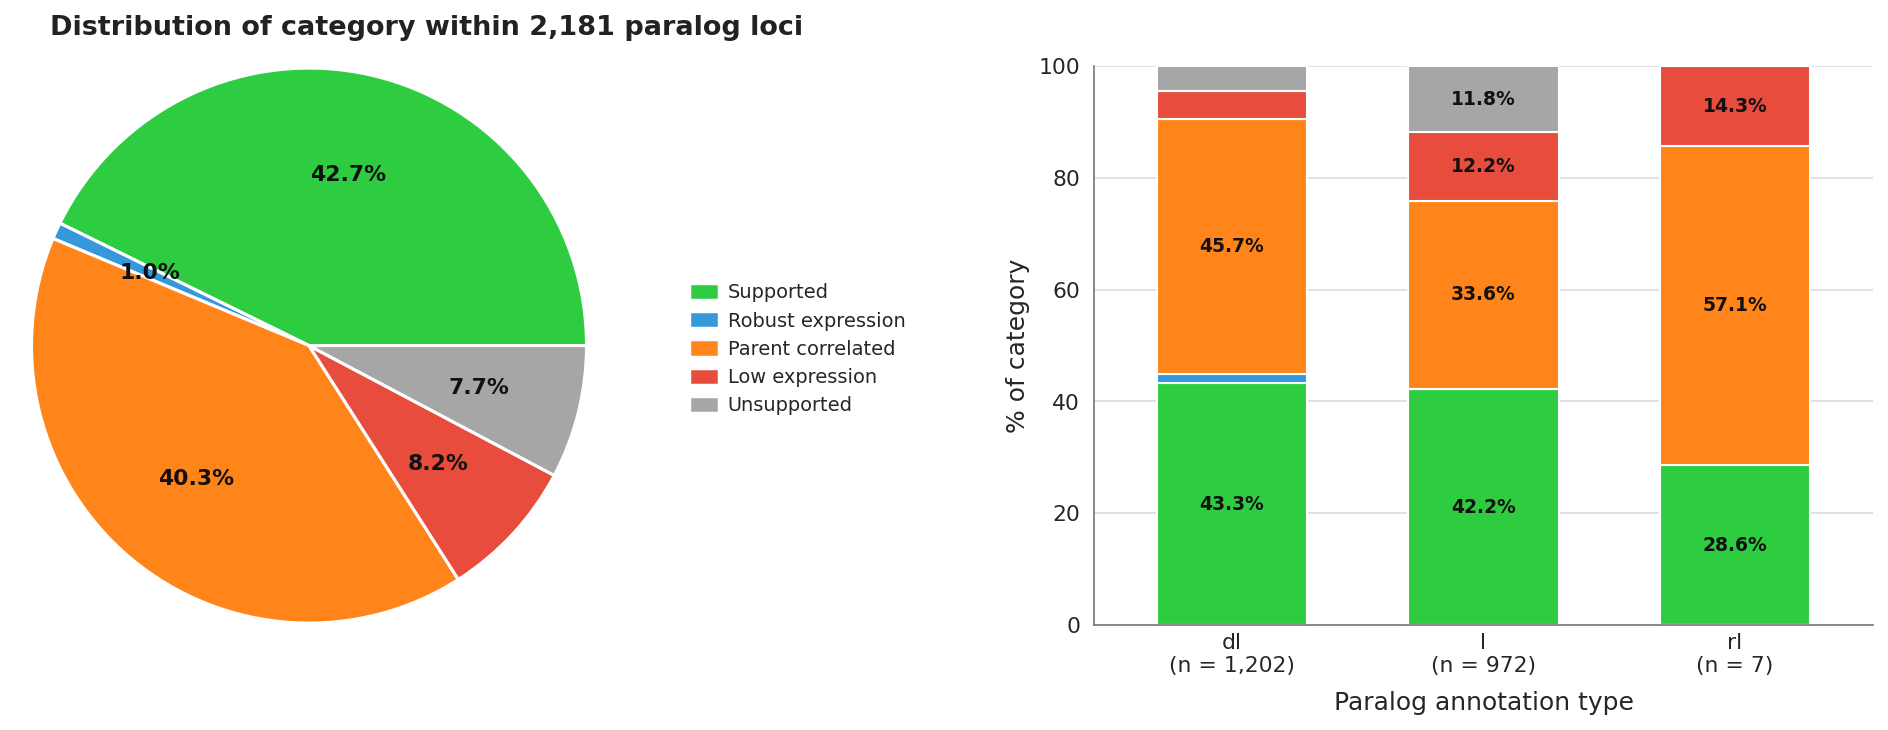


Saved: paralog_classification_overview_2panel.png
Saved: paralog_classification_overview_2panel.pdf
Saved: paralog_classification_overview_2panel.svg

=== Overall classification breakdown ===
  supported           :   932 ( 42.7%)
  robust expression   :    21 (  1.0%)
  parent correlated   :   880 ( 40.3%)
  low expression      :   179 (  8.2%)
  unsupported         :   169 (  7.7%)
  TOTAL               :  2181

=== Breakdown by paralog type ===
  dl                  :  1202
  l                   :   972
  rl                  :     7

=== Classification by paralog type ===

dl (n = 1,202)
  supported           :   520 ( 43.3%; shown)
  robust expression   :    20 (  1.7%; not labeled)
  parent correlated   :   549 ( 45.7%; shown)
  low expression      :    59 (  4.9%; not labeled)
  unsupported         :    54 (  4.5%; not labeled)

l (n = 972)
  supported           :   410 ( 42.2%; shown)
  robust expression   :     1 (  0.1%; not labeled)
  parent correlated   :   327 ( 33.6%; sho

In [14]:
# ============================================================================
# Classification overview — overall pie chart + breakdown by paralog type
#
# Tight manual layout:
#   • Legend moved left, immediately beside the pie
#   • Barplot moved slightly right
#   • Legend no longer overlaps the barplot y-axis label
#   • One shared legend for both panels
#   • Percentage labels shown on pie and readable stacked-bar segments
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ---------------------------------------------------------------------------
# Global publication-style settings
# ---------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ---------------------------------------------------------------------------
# Validate input columns
# ---------------------------------------------------------------------------

required_columns = {
    "classification",
    "paralog_type",
}

missing_columns = required_columns.difference(
    paralog_df.columns
)

if missing_columns:
    raise ValueError(
        "paralog_df is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )


# ---------------------------------------------------------------------------
# Basic counts
# ---------------------------------------------------------------------------

n_missing_paralog_type = int(
    paralog_df["paralog_type"].isna().sum()
)

n_missing_classification = int(
    paralog_df["classification"].isna().sum()
)

if n_missing_classification > 0:
    print(
        f"WARNING: {n_missing_classification:,} rows have no "
        f"classification and will not contribute to the plots."
    )

total_paralogs = int(
    paralog_df["classification"].notna().sum()
)

print(
    f"Total classified paralogs: {total_paralogs:,}"
)

print(
    f"Rows with missing paralog type: "
    f"{n_missing_paralog_type:,}"
)


# ---------------------------------------------------------------------------
# Category colors, order, and labels
# ---------------------------------------------------------------------------

colors_map = {
    "supported": "#2ECC40",
    "robust expression": "#3498DB",
    "parent correlated": "#FF851B",
    "low expression": "#E74C3C",
    "unsupported": "#A6A6A6",
}

category_order = [
    "supported",
    "robust expression",
    "parent correlated",
    "low expression",
    "unsupported",
]

legend_labels = {
    "supported": "Supported",
    "robust expression": "Robust expression",
    "parent correlated": "Parent correlated",
    "low expression": "Low expression",
    "unsupported": "Unsupported",
}


# ---------------------------------------------------------------------------
# Overall classification counts
# ---------------------------------------------------------------------------

observed_classifications = set(
    paralog_df["classification"]
    .dropna()
    .unique()
)

plot_categories = [
    category
    for category in category_order
    if category in observed_classifications
]

unexpected_categories = sorted(
    observed_classifications.difference(
        category_order
    )
)

if unexpected_categories:
    print(
        "\nWARNING: These classifications are present but are not "
        "included in category_order:"
    )

    for category in unexpected_categories:
        print(f"  {category}")

class_counts = (
    paralog_df["classification"]
    .value_counts()
    .reindex(
        plot_categories,
        fill_value=0,
    )
    .astype(int)
)

if class_counts.sum() == 0:
    raise ValueError(
        "No recognized classifications were available for plotting."
    )


# ---------------------------------------------------------------------------
# Create figure with exact manual positioning
#
# Axes format:
# [left, bottom, width, height]
#
# The legend is positioned immediately beside the pie.
# The barplot is shifted right to protect its y-axis title.
# ---------------------------------------------------------------------------

fig = plt.figure(
    figsize=(13.5, 4.9),
    facecolor="white",
)

ax_pie = fig.add_axes([
    0.015,   # left
    0.10,    # bottom
    0.385,   # width
    0.80,    # height
])

ax_legend = fig.add_axes([
    0.392,   # moved left toward pie
    0.245,
    0.135,
    0.50,
])

ax_bar = fig.add_axes([
    0.595,   # shifted right to avoid legend/y-label collision
    0.12,
    0.385,
    0.76,
])

ax_legend.axis("off")


# ============================================================================
# Left panel — Overall classification pie chart
# ============================================================================

pie_colors = [
    colors_map[category]
    for category in class_counts.index
]


def pie_percentage_formatter(percentage):
    """Format nonzero pie-chart percentages."""

    if percentage <= 0:
        return ""

    return f"{percentage:.1f}%"


wedges, _, pie_percentage_texts = ax_pie.pie(
    class_counts.values,

    # Category names are provided by the shared legend
    labels=None,

    colors=pie_colors,
    autopct=pie_percentage_formatter,

    startangle=0,
    counterclock=True,

    # Large pie for publication visibility
    radius=1.18,

    pctdistance=0.63,

    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5,
    },

    textprops={
        "fontsize": 10.5,
        "fontweight": "bold",
        "color": "#111111",
    },
)


for percentage_text in pie_percentage_texts:

    percentage_text.set_fontsize(
        10.5
    )

    percentage_text.set_fontweight(
        "bold"
    )

    percentage_text.set_color(
        "#111111"
    )


ax_pie.set_title(
    "Distribution of category within 2,181 paralog loci",
    fontsize=13,
    fontweight="bold",
    color="#222222",
        x=0.7,   # Horizontal centering
    pad=8,
)

ax_pie.set_aspect(
    "equal"
)


# ============================================================================
# Shared legend — positioned tightly beside the pie
# ============================================================================

shared_legend_handles = [
    mpatches.Patch(
        facecolor=colors_map[category],
        edgecolor="white",
        linewidth=0.7,
        label=legend_labels.get(
            category,
            category,
        ),
    )
    for category in class_counts.index
]


shared_legend = ax_legend.legend(
    handles=shared_legend_handles,

    # Anchor legend against the left edge of its dedicated axis
    loc="center left",
    bbox_to_anchor=(0.00, 0.50),

    ncol=1,
    frameon=False,

    fontsize=9.3,

    labelspacing=0.48,
    handlelength=1.45,
    handleheight=0.85,
    handletextpad=0.48,
    borderaxespad=0.0,
)


# ============================================================================
# Right panel — Classification by paralog annotation type
# ============================================================================

ct = pd.crosstab(
    paralog_df["paralog_type"],
    paralog_df["classification"],
)


preferred_paralog_type_order = [
    "dl",
    "l",
    "rl",
]

paralog_type_order = [
    paralog_type
    for paralog_type in preferred_paralog_type_order
    if paralog_type in ct.index
]

if not paralog_type_order:
    raise ValueError(
        "None of the expected paralog types "
        "('dl', 'l', 'rl') were found."
    )


ct = ct.reindex(
    index=paralog_type_order
)

ct = ct.reindex(
    columns=[
        category
        for category in category_order
        if category in ct.columns
    ],
    fill_value=0,
)


type_totals = (
    ct.sum(axis=1)
    .astype(int)
)


ct_pct = (
    ct.div(
        type_totals.replace(0, np.nan),
        axis=0,
    )
    .mul(100)
    .fillna(0)
)


bar_labels = [
    f"{paralog_type}\n"
    f"(n = {type_totals[paralog_type]:,})"
    for paralog_type in ct.index
]


# ---------------------------------------------------------------------------
# Draw stacked bars
# ---------------------------------------------------------------------------

ct_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax_bar,

    width=0.60,

    color=[
        colors_map[category]
        for category in ct.columns
    ],

    edgecolor="white",
    linewidth=1.0,

    # The shared legend beside the pie is the only legend
    legend=False,
)


# ---------------------------------------------------------------------------
# Add readable percentage labels
# ---------------------------------------------------------------------------

# Omit smaller segments that cannot hold horizontal text cleanly.
MINIMUM_LABEL_PCT = 5.0

for x_index, paralog_type in enumerate(
    ct_pct.index
):

    cumulative_height = 0.0

    for category in ct_pct.columns:

        percentage = float(
            ct_pct.loc[
                paralog_type,
                category,
            ]
        )

        if percentage <= 0:
            continue

        segment_center = (
            cumulative_height
            + percentage / 2
        )

        if percentage >= MINIMUM_LABEL_PCT:

            ax_bar.text(
                x_index,
                segment_center,
                f"{percentage:.1f}%",

                ha="center",
                va="center",

                fontsize=9.0,
                fontweight="bold",
                color="#111111",

                clip_on=True,
                zorder=5,
            )

        cumulative_height += percentage


# ---------------------------------------------------------------------------
# Bar-axis formatting
# ---------------------------------------------------------------------------

# ax_bar.set_title(
#     "Distribution of category within 2,181 paralog loci",
#     fontsize=13,
#     fontweight="bold",
#     color="#222222",
#     pad=8,
# )


ax_bar.set_ylim(
    0,
    100,
)


ax_bar.set_yticks(
    np.arange(
        0,
        101,
        20,
    )
)


ax_bar.set_ylabel(
    "% of category",
    fontsize=12,

    # Keep the title close to the axis and farther from the legend
    labelpad=4,
)


ax_bar.set_xlabel(
    "Paralog annotation type",
    fontsize=12,
    labelpad=7,
)


ax_bar.set_xticks(
    np.arange(
        len(bar_labels)
    )
)


ax_bar.set_xticklabels(
    bar_labels,
    rotation=0,
    fontsize=10.5,
)


ax_bar.tick_params(
    axis="x",
    length=0,
    pad=4,
)


ax_bar.tick_params(
    axis="y",
    labelsize=10.5,
    length=3,
    width=0.8,
    color="#555555",
)


ax_bar.grid(
    axis="y",
    color="#D4D4D4",
    linewidth=0.8,
    linestyle="-",
    alpha=0.8,
)


ax_bar.grid(
    axis="x",
    visible=False,
)


ax_bar.set_axisbelow(
    True
)


ax_bar.spines["top"].set_visible(
    False
)

ax_bar.spines["right"].set_visible(
    False
)


ax_bar.spines["left"].set_color(
    "#777777"
)

ax_bar.spines["bottom"].set_color(
    "#777777"
)


ax_bar.spines["left"].set_linewidth(
    0.8
)

ax_bar.spines["bottom"].set_linewidth(
    0.8
)


# ============================================================================
# Export
# ============================================================================

output_stem = (
    "paralog_classification_overview_2panel"
)


plt.savefig(
    f"{output_stem}.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)


plt.savefig(
    f"{output_stem}.pdf",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)


plt.savefig(
    f"{output_stem}.svg",
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
)


plt.show()


print(
    f"\nSaved: {output_stem}.png"
)

print(
    f"Saved: {output_stem}.pdf"
)

print(
    f"Saved: {output_stem}.svg"
)


# ============================================================================
# Print overall classification summary
# ============================================================================

print(
    "\n=== Overall classification breakdown ==="
)

for category in category_order:

    if category not in class_counts.index:
        continue

    count = int(
        class_counts[category]
    )

    percentage = (
        100
        * count
        / total_paralogs
    )

    print(
        f"  {category:20s}: "
        f"{count:5d} "
        f"({percentage:5.1f}%)"
    )


print(
    f"  {'TOTAL':20s}: "
    f"{total_paralogs:5d}"
)


# ============================================================================
# Print paralog-type summary
# ============================================================================

print(
    "\n=== Breakdown by paralog type ==="
)

for paralog_type in preferred_paralog_type_order:

    count = int(
        (
            paralog_df["paralog_type"]
            == paralog_type
        ).sum()
    )

    print(
        f"  {paralog_type:20s}: "
        f"{count:5d}"
    )


# ============================================================================
# Print stacked-bar values for verification
# ============================================================================

print(
    "\n=== Classification by paralog type ==="
)

for paralog_type in ct_pct.index:

    print(
        f"\n{paralog_type} "
        f"(n = {type_totals[paralog_type]:,})"
    )

    for category in ct_pct.columns:

        count = int(
            ct.loc[
                paralog_type,
                category,
            ]
        )

        percentage = float(
            ct_pct.loc[
                paralog_type,
                category,
            ]
        )

        label_status = (
            "shown"
            if percentage >= MINIMUM_LABEL_PCT
            else "not labeled"
        )

        print(
            f"  {category:20s}: "
            f"{count:5d} "
            f"({percentage:5.1f}%; {label_status})"
        )



## 8. Summary outputs for paper

In [15]:
# Build comprehensive output tables

# --- Per-paralog summary ---
paralog_output = paralog_df.copy()
paralog_output = paralog_output.rename(columns={
    'gene_name': 'paralog_name',
    'mean_tpm': 'mean_TPM',
    'max_tpm': 'max_TPM',
    'n_tissues_detected': 'tissues_detected',
    'n_samples_detected': 'samples_detected',
    'corr_with_parent': 'pearson_r_vs_parent',
    'corr_pvalue': 'pearson_pvalue',
})
paralog_output['pct_samples'] = paralog_output['samples_detected'] / len(sample_list) * 100

# Reorder columns
out_cols = ['family', 'paralog_name', 'paralog_type', 'classification',
            'mean_TPM', 'max_TPM', 'tissues_detected', 'samples_detected', 'pct_samples',
            'pearson_r_vs_parent', 'pearson_pvalue', 'tissue_specificity']
paralog_output[out_cols].to_csv('paralog_support_summary.tsv', sep='\t', index=False, float_format='%.4f')
print(f'Written: paralog_support_summary.tsv ({len(paralog_output)} paralogs)')

# --- Per-family summary ---
family_output = family_summary.copy()
family_output = family_output.rename(columns={
    'n_paralogs': 'total_paralogs',
    'n_paralogs_detected': 'paralogs_detected',
    'n_parent correlated': 'paralogs_parent correlated',
    'mean_paralog_tpm': 'mean_paralog_TPM',
    'max_paralog_tpm': 'max_paralog_TPM',
    'parent_mean_tpm': 'parent_mean_TPM',
    'parent_max_tpm': 'parent_max_TPM',
    'paralog_parent_tpm_ratio': 'paralog_parent_TPM_ratio',
})

# Add classification counts
class_pivot = paralog_df.pivot_table(
    index='family', columns='classification', aggfunc='size', fill_value=0
).reset_index()
family_output = family_output.merge(class_pivot, on='family', how='left')

# Ensure all classification columns exist
for col in ['supported', 'robust expression', 'parent correlated', 'low expression', 'unsupported']:
    if col not in family_output.columns:
        family_output[col] = 0

fam_out_cols = ['family', 'has_parent', 'total_paralogs', 'paralogs_detected',
                'supported', 'robust expression', 'parent correlated', 'low expression', 'unsupported',
                'parent_mean_TPM', 'mean_paralog_TPM', 'paralog_parent_TPM_ratio',
                'paralogs_parent correlated', 'parent_n_tissues']
family_output[fam_out_cols].to_csv('paralog_support_families.tsv', sep='\t', index=False, float_format='%.4f')
print(f'Written: paralog_support_families.tsv ({len(family_output)} families)')

# --- Quick stats for paper ---
print("\n" + "="*60)
print("KEY STATISTICS FOR PAPER")
print("="*60)
print(f"Total paralog families analyzed: {len(family_results)}")
print(f"Total paralogs (all types): {len(paralog_df)}")
print(f"  -l (Liftoff):  {len(paralog_df[paralog_df['paralog_type']=='l'])}")
print(f"  -dl (de novo): {len(paralog_df[paralog_df['paralog_type']=='dl'])}")
print(f"  -rl (retro):   {len(paralog_df[paralog_df['paralog_type']=='rl'])}")
print()
print("Classification:")
for cls in ['supported', 'robust expression', 'parent correlated', 'low expression', 'unsupported']:
    n = (paralog_df['classification'] == cls).sum()
    print(f"  {cls:20s}: {n:5d} ({100*n/len(paralog_df):5.1f}%)")
print()
print(f"Paralogs with parent comparison possible: {(~paralog_df['corr_with_parent'].isna()).sum()}")
high_corr = (paralog_df['corr_with_parent'] > 0.8).sum()
print(f"Paralogs highly correlated with parent (r>0.8): {high_corr}")
print(f"Families with annotated parent: {family_summary['has_parent'].sum()}")
print(f"Families where paralogs exceed parent expression: {(family_output['paralog_parent_TPM_ratio'] > 1).sum()}")

Written: paralog_support_summary.tsv (2181 paralogs)
Written: paralog_support_families.tsv (1091 families)

KEY STATISTICS FOR PAPER
Total paralog families analyzed: 1091
Total paralogs (all types): 2181
  -l (Liftoff):  972
  -dl (de novo): 1202
  -rl (retro):   7

Classification:
  supported           :   932 ( 42.7%)
  robust expression   :    21 (  1.0%)
  parent correlated   :   880 ( 40.3%)
  low expression      :   179 (  8.2%)
  unsupported         :   169 (  7.7%)

Paralogs with parent comparison possible: 1969
Paralogs highly correlated with parent (r>0.8): 894
Families with annotated parent: 1091
Families where paralogs exceed parent expression: 696


## 9. Publication figure: paralog support heatmap

Top 50 families with parent + detected paralogs


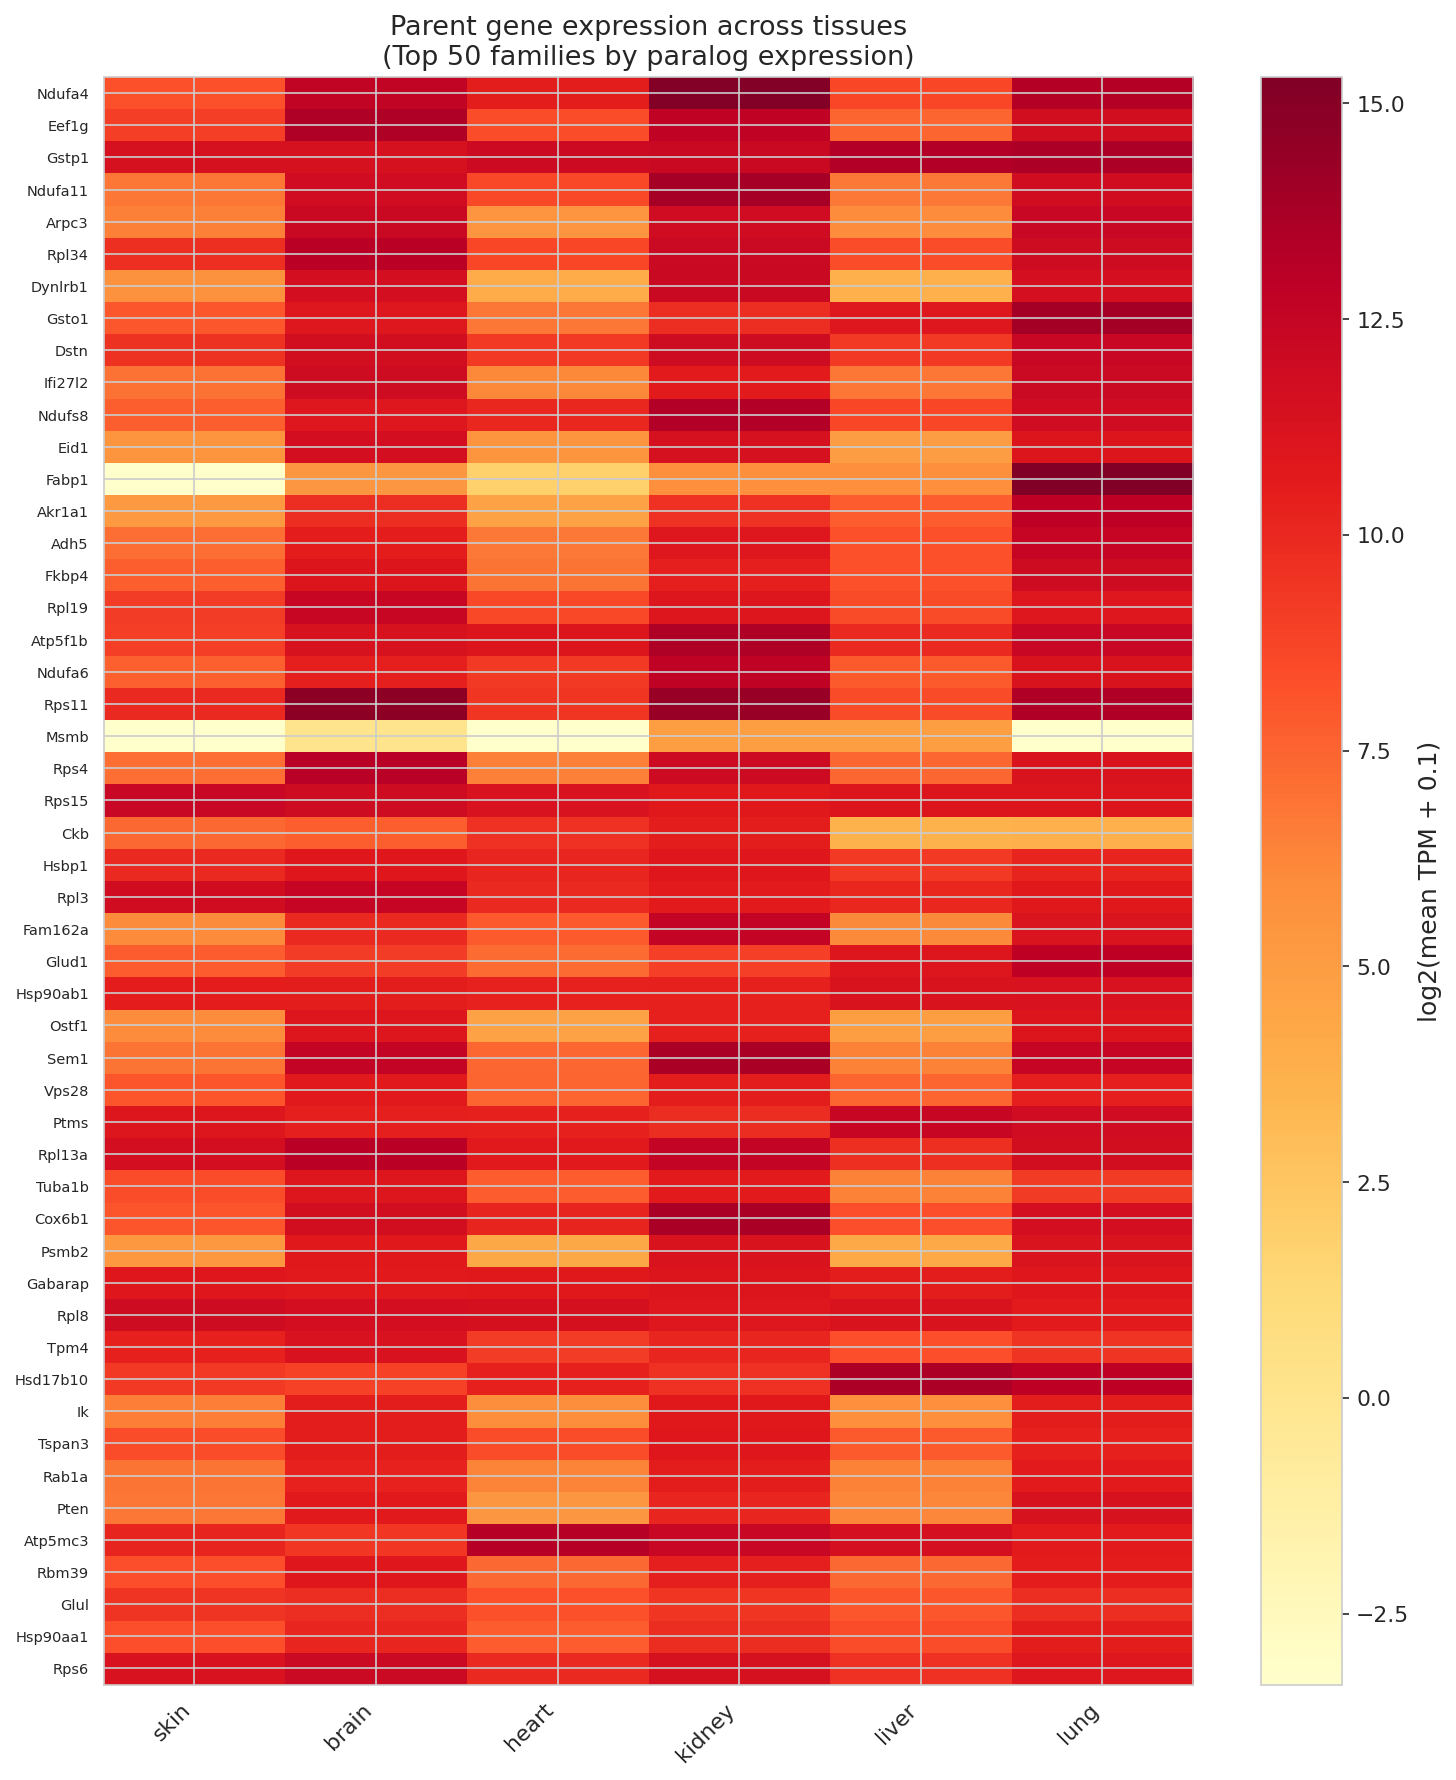

In [16]:
# Create a summary heatmap showing all families with parent + paralogs
# Each row = one family, columns = parent TPM and max paralog TPM per tissue

# Filter to families with parent that have at least 1 detected paralog
plot_fams = family_output[
    family_output['has_parent'] & 
    (family_output['paralogs_detected'] > 0)
].sort_values('mean_paralog_TPM', ascending=False).head(50)

print(f'Top 50 families with parent + detected paralogs')

fig, ax = plt.subplots(figsize=(10, 12))

# Build matrix: for each family, get parent and max paralog TPM per tissue
plot_data = []
row_labels = []
for fam in plot_fams['family']:
    fam_tpm = tpm_full[tpm_full['family'] == fam]
    parent = fam_tpm[fam_tpm['gene_type'] == 'parent']
    paralogs = fam_tpm[fam_tpm['gene_type'] != 'parent']
    
    for tissue in tissues:
        tissue_samps = [s for s, tm in sample_tissue.items() if tm == tissue]
        if len(parent) > 0:
            p_tpm = parent[tissue_samps].mean(axis=1).values[0]
        else:
            p_tpm = 0
        max_para_tpm = paralogs[tissue_samps].mean(axis=1).max() if len(paralogs) > 0 else 0
        plot_data.append([p_tpm, max_para_tpm])
        row_labels.append(f'{fam}')

plot_matrix = np.array(plot_data)
log_matrix = np.log2(plot_matrix + 0.1)

# Reshape to (n_families * n_tissues, 2)
n_fams = len(plot_fams)
parent_mat = log_matrix[::2].reshape(n_fams, len(tissues))

im = ax.imshow(parent_mat, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(tissues)))
ax.set_xticklabels(tissues, rotation=45, ha='right')
ax.set_yticks(range(n_fams))
ax.set_yticklabels(plot_fams['family'].values, fontsize=7)
ax.set_title('Parent gene expression across tissues\n(Top 50 families by paralog expression)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('log2(mean TPM + 0.1)')

plt.tight_layout()
plt.savefig('paralog_parent_expression_heatmap.png', dpi=300)
plt.show()

## 10. Classification criteria and classic examples

### Decision tree for classifying each paralog

The `classify_paralog()` function (cell 14) applies these rules **in order**:

```
Is the paralog detected in ≥1 of 29 samples?
  ├── NO  →  unsupported          (zero RNA-seq reads)
  └── YES → Is it detected in ≥2 tissues AND mean TPM ≥ 0.1?
              ├── NO  →  low expression   (detectable but too weak/narrow)
              └── YES → Is Pearson r vs parent > 0.8 AND parent is expressed?
                          ├── YES → Is mean TPM ≥ 0.5?
                          │         ├── YES →  parent correlated
                          │         └── NO  →  low expression
                          └── NO  → Is mean TPM ≥ 0.5?
                                      ├── YES → Is parent comparison possible?
                                      │         ├── YES →  supported
                                      │         └── NO  →  robust expression
                                      └── NO  →  low expression
```

**Summary of categories:**

| Category | RNA-seq evidence | Tissue breadth | Parent comparison | Interpretation |
|---|---|---|---|---|
| **supported** | Strong (TPM ≥ 0.5) | ≥ 2 tissues | Parent expressed, r ≤ 0.8 | True paralog; expression independent of parent |
| **robust expression** | Strong (TPM ≥ 0.5) | ≥ 2 tissues | No parent OR parent TPM=0 | Good expression but cannot verify independence |
| **parent correlated** | Strong (TPM ≥ 0.5) | ≥ 2 tissues | Parent expressed, r > 0.8 | Co-regulated paralog; mirrors parent pattern |
| **low expression** | Weak or narrow | < 2 tissues OR TPM < 0.1 | Any | Marginal evidence; may be real but low |
| **unsupported** | None | 0 tissues | N/A | Zero reads — likely artifact or pseudogene |

**Key design choices:**
- Pearson r is computed on **log2(TPM + 0.1) across 6 tissues** (not 29 samples) — this captures tissue-level co-regulation while averaging out replicate noise.
- The r > 0.8 threshold is intentionally conservative: with only 6 data points (tissues), correlation can be high simply because both genes share the same broad tissue preference. These paralogs are **not** assumed to be alleles without additional evidence.
- **robust expression** separates paralogs where we have good expression data but cannot perform a parent comparison — either because the family has no annotated parent gene (82 paralogs in 52 families) or the parent gene is undetected in all 29 samples (parent TPM=0). These were previously lumped into "supported", which overstated the evidence for independence.

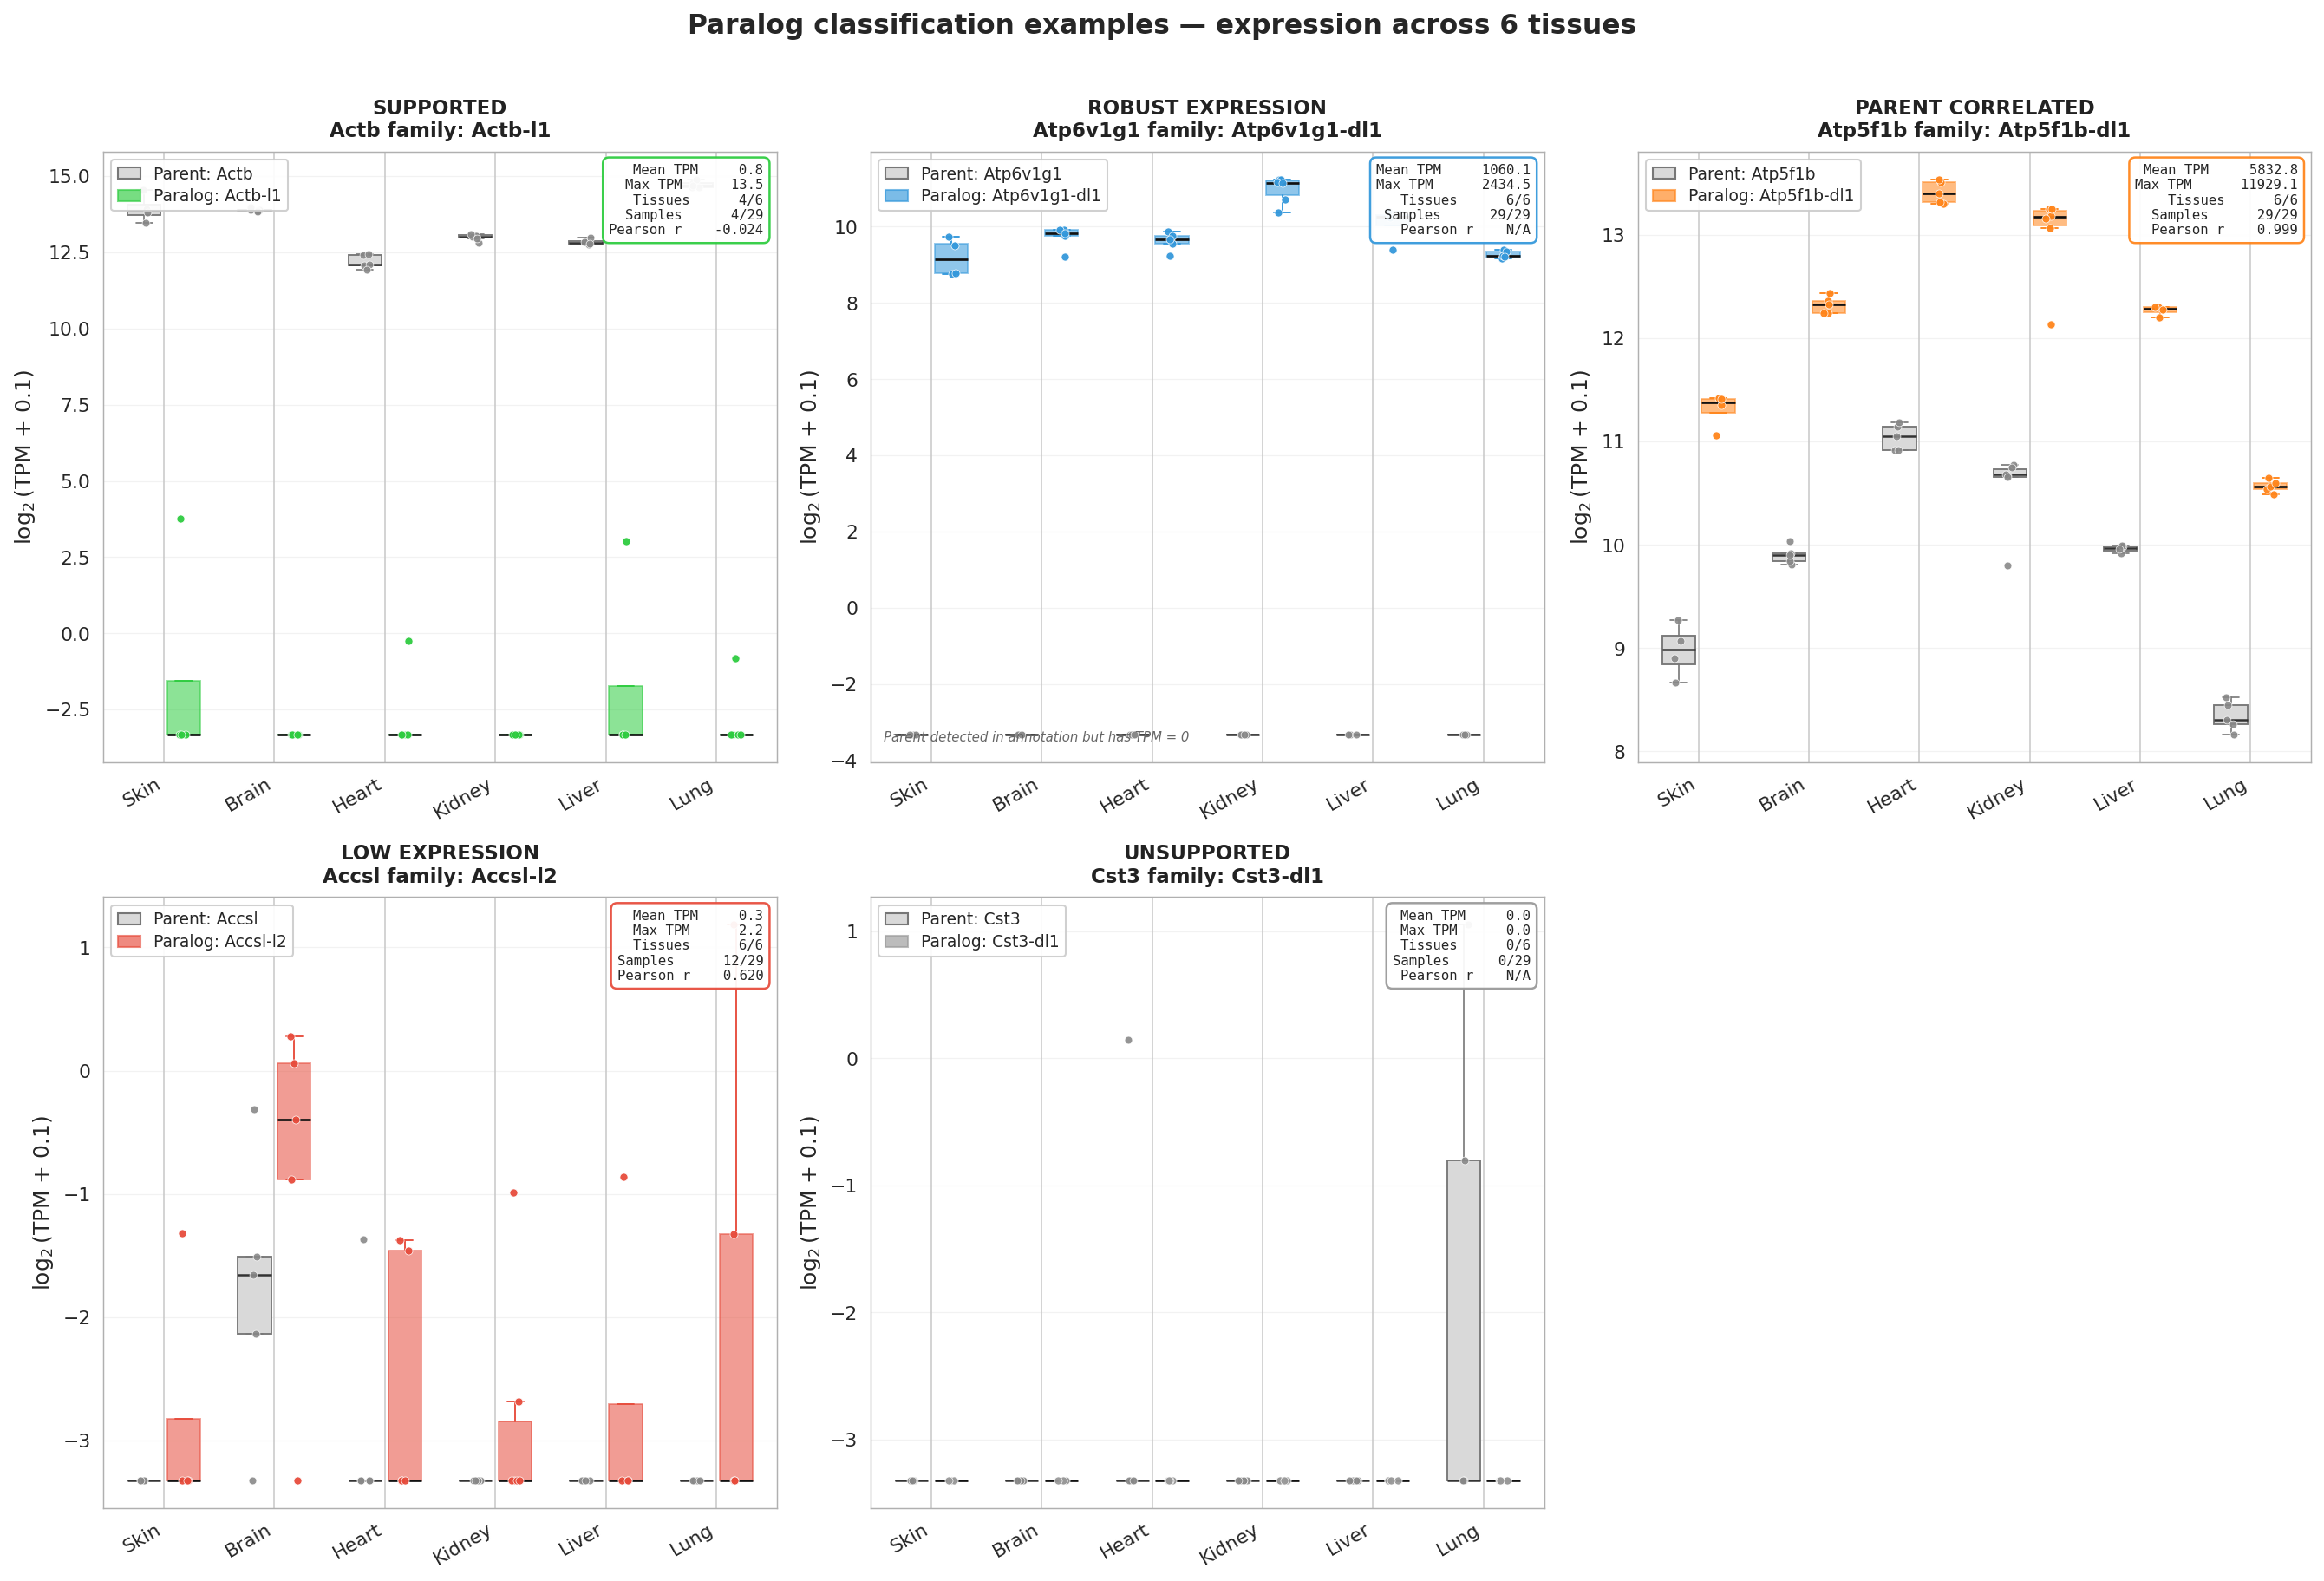

Saved: paralog_classification_examples.png
Saved: paralog_classification_examples.pdf

=== Example summary ===

SUPPORTED: Actb-l1 (Actb family)
  Mean TPM = 0.8; Max TPM = 13.5
  Tissues = 4/6; Samples = 4/29
  Pearson r = -0.024
  Paralog type = l

ROBUST EXPRESSION: Atp6v1g1-dl1 (Atp6v1g1 family)
  Mean TPM = 1060.1; Max TPM = 2434.5
  Tissues = 6/6; Samples = 29/29
  Pearson r = N/A
  Paralog type = dl

PARENT CORRELATED: Atp5f1b-dl1 (Atp5f1b family)
  Mean TPM = 5832.8; Max TPM = 11929.1
  Tissues = 6/6; Samples = 29/29
  Pearson r = 0.999
  Paralog type = dl

LOW EXPRESSION: Accsl-l2 (Accsl family)
  Mean TPM = 0.3; Max TPM = 2.2
  Tissues = 6/6; Samples = 12/29
  Pearson r = 0.620
  Paralog type = l

UNSUPPORTED: Cst3-dl1 (Cst3 family)
  Mean TPM = 0.0; Max TPM = 0.0
  Tissues = 0/6; Samples = 0/29
  Pearson r = N/A
  Paralog type = dl


In [17]:
# ============================================================================
# Publication figure: paralog classification examples (5 panels)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Explicit tissue list (NOT from mutable global `tissues`)
tissue_order = ["skin", "brain", "heart", "kidney", "liver", "lung"]

# ---------------------------------------------------------------------------
# Classification categories and selected examples
# ---------------------------------------------------------------------------
examples = [
    ("supported",         "Actb",       "Actb-l1",        "#2ECC40"),
    ("robust expression", "Atp6v1g1",   "Atp6v1g1-dl1",   "#3498DB"),
    ("parent correlated", "Atp5f1b",    "Atp5f1b-dl1",    "#FF851B"),
    ("low expression",    "Accsl",      "Accsl-l2",       "#E74C3C"),
    ("unsupported",       "Cst3",       "Cst3-dl1",       "#999999"),
]

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------
def get_sample_values(gene_name, tpm_df, sample_tissue_dict, tissue_names):
    """Return one NumPy array per tissue containing per-sample TPM values."""
    row = tpm_df.loc[tpm_df["gene_name"] == gene_name]
    if row.empty:
        return [np.zeros(sum(t == tissue for t in sample_tissue_dict.values()), dtype=float)
                for tissue in tissue_names]
    tissue_values = []
    for tissue in tissue_names:
        tissue_samples = [s for s, tm in sample_tissue_dict.items()
                         if tm == tissue and s in tpm_df.columns]
        if len(tissue_samples) == 0:
            tissue_values.append(np.array([], dtype=float))
        else:
            vals = (row[tissue_samples]
                    .apply(pd.to_numeric, errors="coerce")
                    .to_numpy(dtype=float)
                    .flatten())
            vals = vals[np.isfinite(vals)]
            tissue_values.append(vals)
    return tissue_values


def transform_tpm(values):
    """log2-transform TPM for plotting."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.array([np.log2(0.1)])
    return np.log2(values + 0.1)


def get_metric_row(gene_name, summary_df):
    """Retrieve exactly one summary row for a paralog."""
    matches = summary_df.loc[summary_df["gene_name"] == gene_name]
    if matches.empty:
        raise ValueError(f"Paralog {gene_name!r} not found in paralog_df.")
    return matches.iloc[0]


def format_correlation(value):
    """Format correlation safely."""
    if pd.isna(value):
        return "N/A"
    return f"{float(value):.3f}"


# ---------------------------------------------------------------------------
# Validate selected examples
# ---------------------------------------------------------------------------
missing = [name for _, _, name, _ in examples
           if paralog_df.loc[paralog_df["gene_name"] == name].empty]
if missing:
    raise ValueError("Missing paralogs: " + ", ".join(missing))

# ---------------------------------------------------------------------------
# Figure layout — 2 rows x 3 columns (6th panel hidden)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
axes[5].set_visible(False)

rng_parent = np.random.default_rng(42)
rng_paralog = np.random.default_rng(123)

n_tissues = len(tissue_order)
base_positions = np.arange(n_tissues)
box_width = 0.30
position_offset = 0.18
jitter_width = 0.045

for ax, (category, family, paralog_name, category_color) in zip(axes[:5], examples):

    metric_row = get_metric_row(paralog_name, paralog_df)

    paralog_values_raw = get_sample_values(paralog_name, tpm_full, sample_tissue, tissue_order)
    parent_values_raw = get_sample_values(family, tpm_full, sample_tissue, tissue_order)

    parent_available = bool((tpm_full["gene_name"] == family).any())
    parent_expressed = (
        parent_available
        and any(np.any(np.asarray(v, dtype=float) > 0) for v in parent_values_raw)
    )

    paralog_plot = [transform_tpm(v) for v in paralog_values_raw]
    parent_plot = [transform_tpm(v) for v in parent_values_raw]

    parent_positions = base_positions - position_offset
    paralog_positions = base_positions + position_offset

    # ---- Parent boxplots ----
    if parent_available:
        ax.boxplot(
            parent_plot, positions=parent_positions, widths=box_width,
            patch_artist=True, showfliers=False, manage_ticks=False,
            boxprops={"facecolor": "#D9D9D9", "edgecolor": "#777777", "linewidth": 0.9},
            whiskerprops={"color": "#777777", "linewidth": 0.8},
            capprops={"color": "#777777", "linewidth": 0.8},
            medianprops={"color": "#333333", "linewidth": 1.2},
        )
        for ti, vals in enumerate(parent_values_raw):
            vals = np.asarray(vals, dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue
            transformed = transform_tpm(vals)
            x_jit = rng_parent.uniform(-jitter_width, jitter_width, transformed.size)
            ax.scatter(
                np.full(transformed.size, parent_positions[ti]) + x_jit,
                transformed, s=18, facecolor="#888888", edgecolor="white",
                linewidth=0.35, alpha=0.9, zorder=3,
            )

    # ---- Paralog boxplots ----
    ax.boxplot(
        paralog_plot, positions=paralog_positions, widths=box_width,
        patch_artist=True, showfliers=False, manage_ticks=False,
        boxprops={"facecolor": category_color, "edgecolor": category_color,
                  "linewidth": 0.9, "alpha": 0.55},
        whiskerprops={"color": category_color, "linewidth": 0.9},
        capprops={"color": category_color, "linewidth": 0.9},
        medianprops={"color": "#111111", "linewidth": 1.3},
    )
    for ti, vals in enumerate(paralog_values_raw):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        transformed = transform_tpm(vals)
        x_jit = rng_paralog.uniform(-jitter_width, jitter_width, transformed.size)
        ax.scatter(
            np.full(transformed.size, paralog_positions[ti]) + x_jit,
            transformed, s=19, facecolor=category_color, edgecolor="white",
            linewidth=0.35, alpha=0.95, zorder=3,
        )

    # ---- Axis formatting ----
    ax.set_xlim(-0.55, n_tissues - 0.45)
    ax.set_xticks(base_positions)
    ax.set_xticklabels([str(t).capitalize() for t in tissue_order], rotation=30, ha="right")
    ax.set_ylabel(r"$\log_2$(TPM + 0.1)")
    ax.grid(axis="y", linewidth=0.6, alpha=0.25)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.7)

    # ---- Title ----
    ax.set_title(
        f"{category.upper()}\n{family} family: {paralog_name}",
        fontsize=11, fontweight="bold", color="#222222", pad=8,
    )

    # ---- Legend ----
    parent_legend = f"Parent: {family}" if parent_available else "Parent unavailable"
    legend_handles = [
        mpatches.Patch(facecolor="#D9D9D9", edgecolor="#777777", label=parent_legend),
        mpatches.Patch(facecolor=category_color, edgecolor=category_color,
                       alpha=0.65, label=f"Paralog: {paralog_name}"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", frameon=True,
              framealpha=0.92, borderpad=0.4, labelspacing=0.35, handlelength=1.4)

    # ---- Statistics box ----
    corr_str = format_correlation(metric_row["corr_with_parent"])
    stats = "\n".join([
        f'Mean TPM     {metric_row["mean_tpm"]:.1f}',
        f'Max TPM      {metric_row["max_tpm"]:.1f}',
        f'Tissues      {int(metric_row["n_tissues_detected"])}/{n_tissues}',
        f'Samples      {int(metric_row["n_samples_detected"])}/{len(sample_tissue)}',
        f'Pearson r    {corr_str}',
    ])
    ax.text(
        0.98, 0.98, stats, transform=ax.transAxes, ha="right", va="top",
        fontsize=7.5, fontfamily="monospace",
        bbox={"boxstyle": "round,pad=0.45", "facecolor": "white",
              "edgecolor": category_color, "linewidth": 1.2, "alpha": 0.94},
    )

    # ---- Note when parent has zero expression ----
    if parent_available and not parent_expressed:
        ax.text(0.02, 0.03, "Parent detected in annotation but has TPM = 0",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=7.2, color="#666666", style="italic")

fig.suptitle(
    "Paralog classification examples — expression across 6 tissues",
    fontsize=15, fontweight="bold", y=1.01,
)

plt.tight_layout()
plt.savefig("paralog_classification_examples.png", dpi=300, bbox_inches="tight")
plt.savefig("paralog_classification_examples.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("Saved: paralog_classification_examples.png")
print("Saved: paralog_classification_examples.pdf")

# Print example statistics
print("\n=== Example summary ===")
for category, family, paralog_name, color in examples:
    mr = get_metric_row(paralog_name, paralog_df)
    cs = format_correlation(mr["corr_with_parent"])
    print(f"\n{category.upper()}: {paralog_name} ({family} family)")
    print(f'  Mean TPM = {mr["mean_tpm"]:.1f}; Max TPM = {mr["max_tpm"]:.1f}')
    print(f'  Tissues = {int(mr["n_tissues_detected"])}/{len(tissue_order)}; '
          f'Samples = {int(mr["n_samples_detected"])}/{len(sample_tissue)}')
    print(f"  Pearson r = {cs}")
    print(f'  Paralog type = {mr["paralog_type"]}')

Tissue order: ['skin', 'brain', 'heart', 'kidney', 'liver', 'lung']


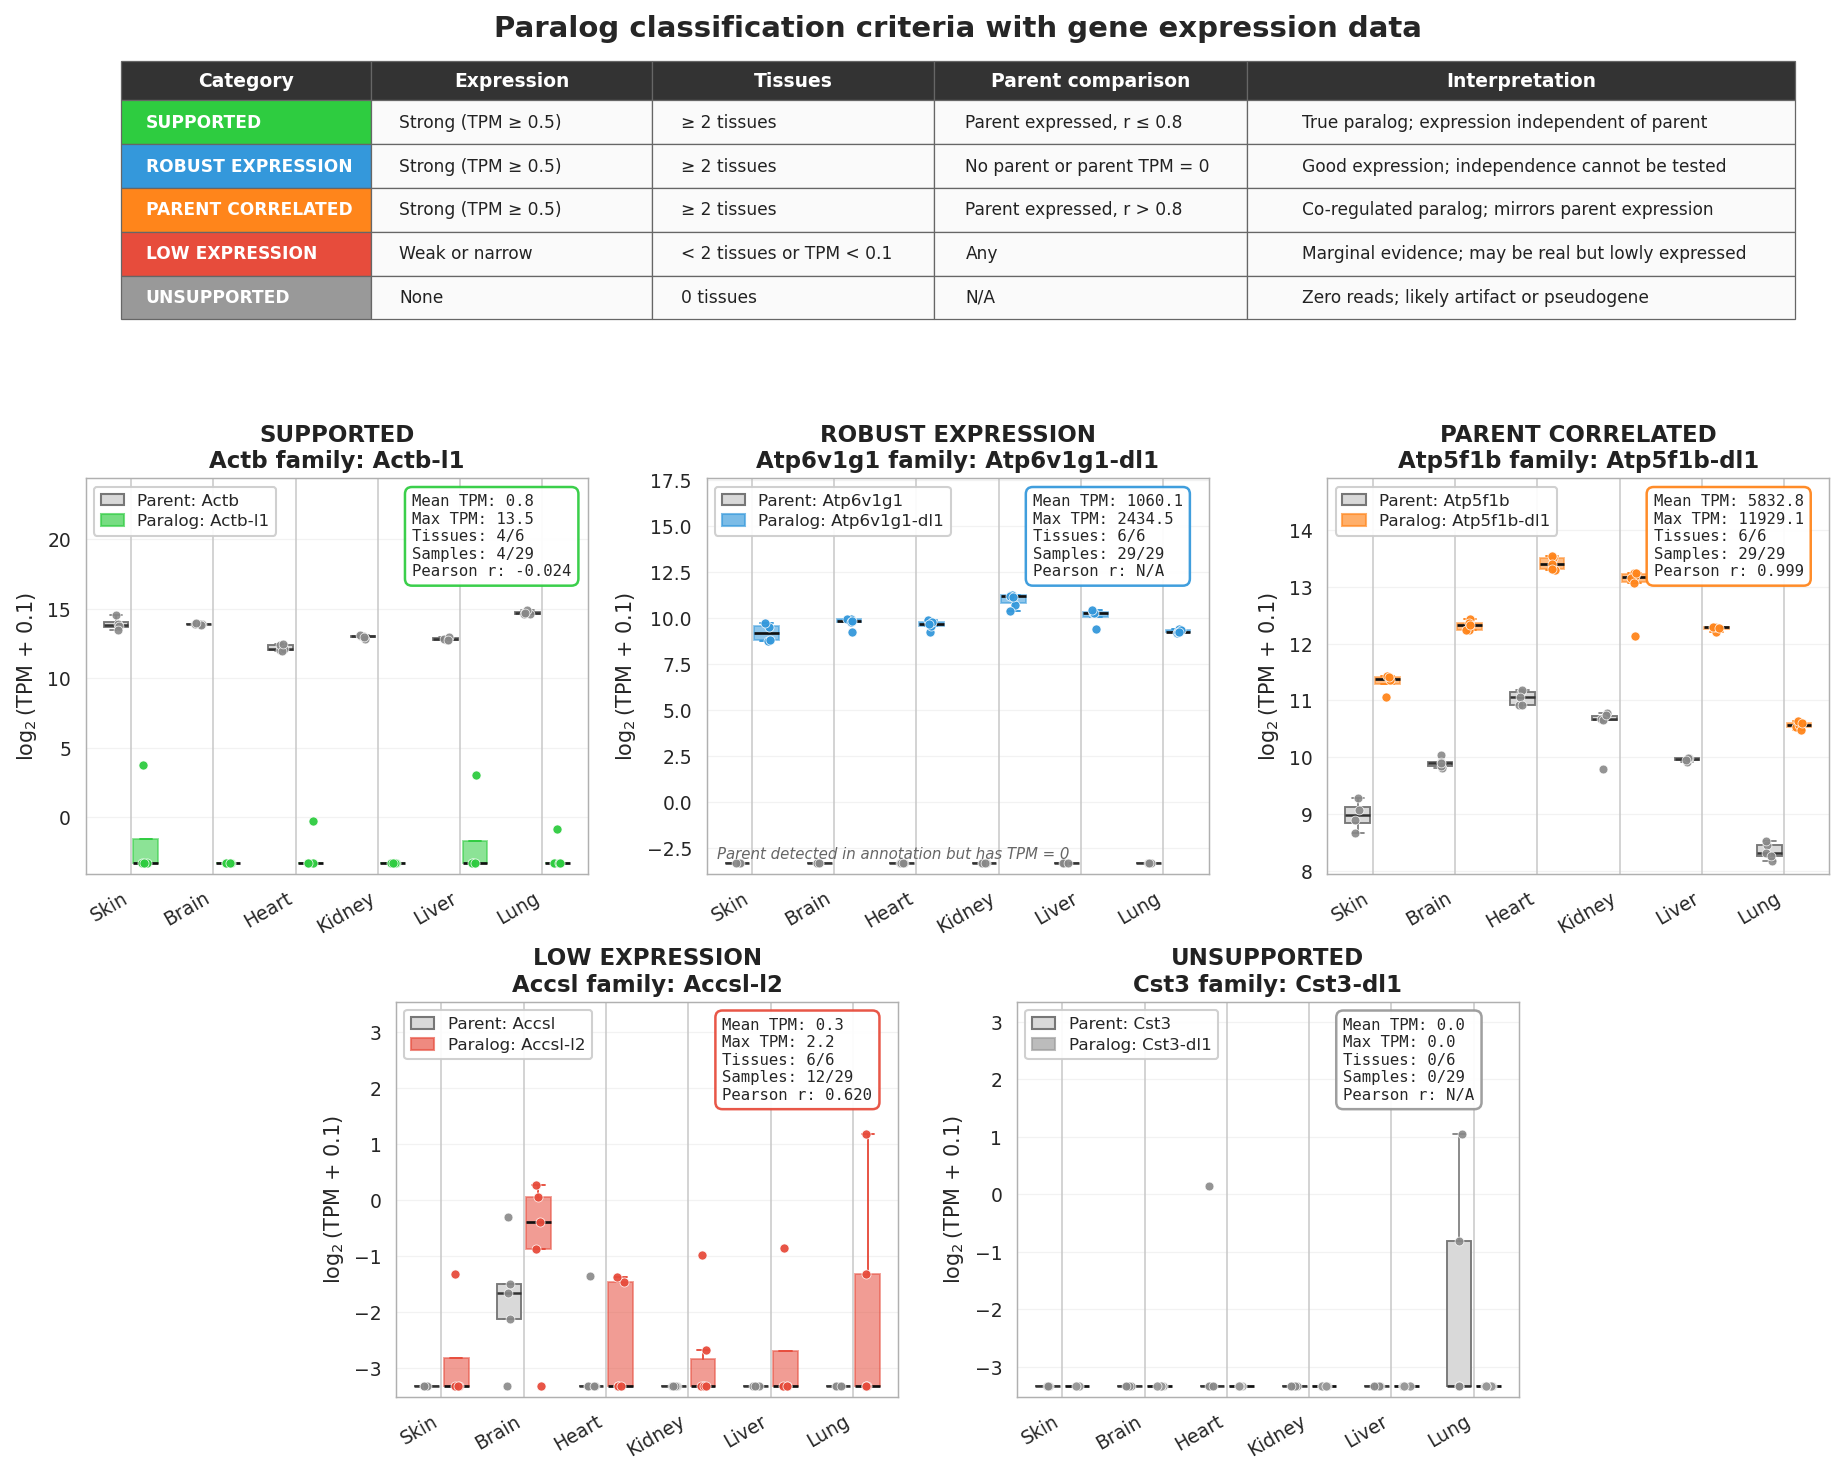

Saved: paralog_classification_examples.pdf
Saved: paralog_classification_examples.png

=== Example summary ===

SUPPORTED: Actb-l1 (Actb family)
  Mean TPM = 0.8; Max TPM = 13.5
  Tissues = 4/6; Samples = 4/29
  Pearson r versus parent = -0.024
  Paralog type = l

ROBUST EXPRESSION: Atp6v1g1-dl1 (Atp6v1g1 family)
  Mean TPM = 1060.1; Max TPM = 2434.5
  Tissues = 6/6; Samples = 29/29
  Pearson r versus parent = N/A
  Paralog type = dl

PARENT CORRELATED: Atp5f1b-dl1 (Atp5f1b family)
  Mean TPM = 5832.8; Max TPM = 11929.1
  Tissues = 6/6; Samples = 29/29
  Pearson r versus parent = 0.999
  Paralog type = dl

LOW EXPRESSION: Accsl-l2 (Accsl family)
  Mean TPM = 0.3; Max TPM = 2.2
  Tissues = 6/6; Samples = 12/29
  Pearson r versus parent = 0.620
  Paralog type = l

UNSUPPORTED: Cst3-dl1 (Cst3 family)
  Mean TPM = 0.0; Max TPM = 0.0
  Tissues = 0/6; Samples = 0/29
  Pearson r versus parent = N/A
  Paralog type = dl


In [18]:
# ============================================================================
# Paralog classification criteria and representative examples
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------------
# Global plotting settings
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ---------------------------------------------------------------------------
# Tissue order
# ---------------------------------------------------------------------------
tissue_order = [
    "skin",
    "brain",
    "heart",
    "kidney",
    "liver",
    "lung"
]

expected_tissues = {
    "skin",
    "brain",
    "heart",
    "kidney",
    "liver",
    "lung"
}

if set(tissue_order) != expected_tissues or len(tissue_order) != 6:
    raise ValueError(
        f"tissue_order is corrupted: {tissue_order}. "
        f"Expected: {sorted(expected_tissues)}"
    )

print("Tissue order:", tissue_order)

# ---------------------------------------------------------------------------
# Classification categories and selected examples
#
# Fields:
# category, parent/family, paralog, color,
# expression criterion, tissue criterion,
# parent comparison, interpretation
# ---------------------------------------------------------------------------
examples = [
    (
        "supported",
        "Actb",
        "Actb-l1",
        "#2ECC40",
        "Strong (TPM ≥ 0.5)",
        "≥ 2 tissues",
        "Parent expressed, r ≤ 0.8",
        "True paralog; expression independent of parent"
    ),
    (
        "robust expression",
        "Atp6v1g1",
        "Atp6v1g1-dl1",
        "#3498DB",
        "Strong (TPM ≥ 0.5)",
        "≥ 2 tissues",
        "No parent or parent TPM = 0",
        "Good expression; independence cannot be tested"
    ),
    (
        "parent correlated",
        "Atp5f1b",
        "Atp5f1b-dl1",
        "#FF851B",
        "Strong (TPM ≥ 0.5)",
        "≥ 2 tissues",
        "Parent expressed, r > 0.8",
        "Co-regulated paralog; mirrors parent expression"
    ),
    (
        "low expression",
        "Accsl",
        "Accsl-l2",
        "#E74C3C",
        "Weak or narrow",
        "< 2 tissues or TPM < 0.1",
        "Any",
        "Marginal evidence; may be real but lowly expressed"
    ),
    (
        "unsupported",
        "Cst3",
        "Cst3-dl1",
        "#999999",
        "None",
        "0 tissues",
        "N/A",
        "Zero reads; likely artifact or pseudogene"
    )
]

# ============================================================================
# Helper functions
# ============================================================================
def get_sample_values(
    gene_name,
    tpm_df,
    sample_tissue_dict,
    tissue_names
):
    """
    Return one NumPy array per tissue containing per-sample TPM values.

    Zeros are retained because zero expression is biologically meaningful for
    these classification categories.
    """
    row = tpm_df.loc[
        tpm_df["gene_name"] == gene_name
    ]

    if row.empty:
        return [
            np.zeros(
                sum(
                    assigned_tissue == tissue
                    for assigned_tissue in sample_tissue_dict.values()
                ),
                dtype=float
            )
            for tissue in tissue_names
        ]

    tissue_values = []

    for tissue in tissue_names:
        tissue_samples = [
            sample
            for sample, assigned_tissue in sample_tissue_dict.items()
            if assigned_tissue == tissue
            and sample in tpm_df.columns
        ]

        if len(tissue_samples) == 0:
            tissue_values.append(
                np.array([], dtype=float)
            )

        else:
            values = (
                row[tissue_samples]
                .apply(pd.to_numeric, errors="coerce")
                .to_numpy(dtype=float)
                .flatten()
            )

            values = values[
                np.isfinite(values)
            ]

            tissue_values.append(values)

    return tissue_values


def transform_tpm(values):
    """Transform raw TPM while retaining zero-expression values."""
    values = np.asarray(
        values,
        dtype=float
    )

    if values.size == 0:
        return np.array([
            np.log2(0.1)
        ])

    return np.log2(
        values + 0.1
    )


def gene_exists(gene_name, tpm_df):
    """Return True when a gene exists in the TPM dataframe."""
    return bool(
        (
            tpm_df["gene_name"] == gene_name
        ).any()
    )


def get_metric_row(gene_name, summary_df):
    """Retrieve exactly one summary row for a paralog."""
    matches = summary_df.loc[
        summary_df["gene_name"] == gene_name
    ]

    if matches.empty:
        raise ValueError(
            f"Paralog {gene_name!r} was not found in paralog_df."
        )

    return matches.iloc[0]


def format_correlation(value):
    """Format correlation safely."""
    if pd.isna(value):
        return "N/A"

    return f"{float(value):.3f}"


def expand_ylim_around_top_boxes(
    ax,
    plotted_points,
    top_artists,
    renderer,
    vertical_clearance=0.035,
    horizontal_clearance=0.015,
    normal_top_fraction=0.94
):
    """
    Expand the upper y-limit so plotted points do not fall underneath artists
    positioned near the top of an axis.

    Parameters
    ----------
    ax
        Matplotlib axis to adjust.

    plotted_points
        Iterable of (x, y) data coordinates for all displayed observations.

    top_artists
        Artists that occupy space at the top of the panel, such as a legend
        or the bounding-box patch around the statistics text.

    renderer
        Renderer obtained after calling fig.canvas.draw().

    vertical_clearance
        Extra separation, in axes coordinates, between a protected box and
        the highest point horizontally underneath it.

    horizontal_clearance
        Small horizontal expansion of each protected box when deciding which
        points lie beneath it.

    normal_top_fraction
        Highest allowed axes-coordinate position for points that are not
        underneath a protected box.
    """
    finite_points = [
        (float(x), float(y))
        for x, y in plotted_points
        if np.isfinite(x) and np.isfinite(y)
    ]

    if not finite_points:
        return

    current_lower, current_upper = ax.get_ylim()

    all_y = np.array([
        y
        for _, y in finite_points
    ])

    global_max = np.max(all_y)

    # Always retain a small amount of normal headroom.
    required_upper = (
        current_lower
        + (
            global_max - current_lower
        ) / normal_top_fraction
    )

    for artist in top_artists:
        if artist is None:
            continue

        artist_bbox_display = artist.get_window_extent(
            renderer=renderer
        )

        artist_bbox_axes = artist_bbox_display.transformed(
            ax.transAxes.inverted()
        )

        protected_left = (
            artist_bbox_axes.x0
            - horizontal_clearance
        )

        protected_right = (
            artist_bbox_axes.x1
            + horizontal_clearance
        )

        # The point should stay below the bottom edge of the protected box.
        target_y_fraction = (
            artist_bbox_axes.y0
            - vertical_clearance
        )

        if target_y_fraction <= 0:
            continue

        covered_y_values = []

        for x_value, y_value in finite_points:
            # Convert the data x coordinate into axes coordinates.
            x_display = ax.transData.transform(
                (x_value, current_lower)
            )[0]

            x_axes = ax.transAxes.inverted().transform(
                (x_display, 0)
            )[0]

            if (
                protected_left
                <= x_axes
                <= protected_right
            ):
                covered_y_values.append(
                    y_value
                )

        if not covered_y_values:
            continue

        covered_max = np.max(
            covered_y_values
        )

        # Solve:
        #
        # (covered_max - lower) / (upper - lower)
        #     <= target_y_fraction
        #
        # for the required upper y-limit.
        box_required_upper = (
            current_lower
            + (
                covered_max - current_lower
            ) / target_y_fraction
        )

        required_upper = max(
            required_upper,
            box_required_upper
        )

    # Never reduce the current upper limit.
    final_upper = max(
        current_upper,
        required_upper
    )

    ax.set_ylim(
        current_lower,
        final_upper
    )


# ============================================================================
# Validate selected examples
# ============================================================================
missing_paralogs = [
    paralog_name
    for _, _, paralog_name, *_ in examples
    if paralog_df.loc[
        paralog_df["gene_name"] == paralog_name
    ].empty
]

if missing_paralogs:
    raise ValueError(
        "The following example paralogs were not found in paralog_df: "
        + ", ".join(missing_paralogs)
    )

# ============================================================================
# Figure layout
# ============================================================================
fig = plt.figure(
    figsize=(12.5, 10.5)
)

gs = GridSpec(
    nrows=3,
    ncols=6,
    figure=fig,
    height_ratios=[
        1.75,
        2.25,
        2.25
    ],
    hspace=0.35,
    wspace=0.62
)

ax_table = fig.add_subplot(
    gs[0, :]
)

example_axes = [
    fig.add_subplot(
        gs[1, 0:2]
    ),
    fig.add_subplot(
        gs[1, 2:4]
    ),
    fig.add_subplot(
        gs[1, 4:6]
    ),
    fig.add_subplot(
        gs[2, 1:3]
    ),
    fig.add_subplot(
        gs[2, 3:5]
    )
]

# ============================================================================
# Classification criteria table
# ============================================================================
ax_table.axis("off")

column_labels = [
    "Category",
    "Expression",
    "Tissues",
    "Parent comparison",
    "Interpretation"
]

table_data = []
table_colors = []

for example in examples:
    (
        category,
        _family,
        _paralog,
        category_color,
        expression_rule,
        tissue_rule,
        parent_rule,
        interpretation
    ) = example

    table_data.append([
        category.upper(),
        expression_rule,
        tissue_rule,
        parent_rule,
        interpretation
    ])

    table_colors.append([
        category_color,
        "#FAFAFA",
        "#FAFAFA",
        "#FAFAFA",
        "#FAFAFA"
    ])

criteria_table = ax_table.table(
    cellText=table_data,
    colLabels=column_labels,
    cellColours=table_colors,
    cellLoc="left",
    colLoc="center",
    loc="center",
    bbox=[
        0.02,
        0.1,
        0.96,
        0.84
    ]
)

criteria_table.auto_set_font_size(False)

criteria_table.set_fontsize(
    8.5
)

column_widths = [
    0.16,
    0.18,
    0.18,
    0.20,
    0.35
]

for column_index, width in enumerate(
    column_widths
):
    for row_index in range(
        len(examples) + 1
    ):
        cell = criteria_table[
            row_index,
            column_index
        ]

        cell.set_width(
            width
        )

        cell.set_edgecolor(
            "#666666"
        )

        cell.set_linewidth(
            0.6
        )

# Header styling
for column_index in range(
    len(column_labels)
):
    cell = criteria_table[
        0,
        column_index
    ]

    cell.set_facecolor(
        "#333333"
    )

    cell.set_text_props(
        color="white",
        fontweight="bold",
        fontsize=9,
        ha="center",
        va="center"
    )

# Body styling
for row_index, example in enumerate(
    examples,
    start=1
):
    category_color = example[3]

    category_cell = criteria_table[
        row_index,
        0
    ]

    category_cell.set_facecolor(
        category_color
    )

    category_cell.set_text_props(
        color="white",
        fontweight="bold",
        fontsize=8.2,
        va="center"
    )

    for column_index in range(
        1,
        len(column_labels)
    ):
        criteria_table[
            row_index,
            column_index
        ].set_text_props(
            color="#222222",
            fontsize=8.2,
            va="center"
        )

# Compact table rows
for row_index in range(
    len(examples) + 1
):
    for column_index in range(
        len(column_labels)
    ):
        cell = criteria_table[
            row_index,
            column_index
        ]

        if row_index == 0:
            cell.set_height(
                0.09
            )

        else:
            cell.set_height(
                0.10
            )

ax_table.set_title(
    "Paralog classification criteria with gene expression data",
    fontsize=14,
    fontweight="bold",
    pad=-10
)

# ============================================================================
# Example panels
# ============================================================================
rng_parent = np.random.default_rng(
    42
)

rng_paralog = np.random.default_rng(
    123
)

n_tissues = len(
    tissue_order
)

base_positions = np.arange(
    n_tissues
)

box_width = 0.30
position_offset = 0.18
jitter_width = 0.045

# Store the information needed for collision-aware y-axis adjustment.
panel_autoscale_jobs = []

for ax, example in zip(
    example_axes,
    examples
):
    (
        category,
        family,
        paralog_name,
        category_color,
        _expression_rule,
        _tissue_rule,
        _parent_rule,
        _interpretation
    ) = example

    metric_row = get_metric_row(
        paralog_name,
        paralog_df
    )

    paralog_values_raw = get_sample_values(
        paralog_name,
        tpm_full,
        sample_tissue,
        tissue_order
    )

    parent_available = gene_exists(
        family,
        tpm_full
    )

    parent_values_raw = get_sample_values(
        family,
        tpm_full,
        sample_tissue,
        tissue_order
    )

    parent_expressed = (
        parent_available
        and any(
            np.any(
                np.asarray(
                    values,
                    dtype=float
                ) > 0
            )
            for values in parent_values_raw
        )
    )

    paralog_values_plot = [
        transform_tpm(values)
        for values in paralog_values_raw
    ]

    parent_values_plot = [
        transform_tpm(values)
        for values in parent_values_raw
    ]

    parent_positions = (
        base_positions
        - position_offset
    )

    paralog_positions = (
        base_positions
        + position_offset
    )

    # Keep all visible observation coordinates for collision detection.
    plotted_points = []

    # -----------------------------------------------------------------------
    # Parent distributions
    # -----------------------------------------------------------------------
    if parent_available:
        ax.boxplot(
            parent_values_plot,
            positions=parent_positions,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
            boxprops={
                "facecolor": "#D9D9D9",
                "edgecolor": "#777777",
                "linewidth": 0.9
            },
            whiskerprops={
                "color": "#777777",
                "linewidth": 0.8
            },
            capprops={
                "color": "#777777",
                "linewidth": 0.8
            },
            medianprops={
                "color": "#333333",
                "linewidth": 1.2
            }
        )

        for tissue_index, values in enumerate(
            parent_values_raw
        ):
            values = np.asarray(
                values,
                dtype=float
            )

            values = values[
                np.isfinite(values)
            ]

            if values.size == 0:
                continue

            transformed = transform_tpm(
                values
            )

            x_jitter = rng_parent.uniform(
                -jitter_width,
                jitter_width,
                transformed.size
            )

            scatter_x = (
                np.full(
                    transformed.size,
                    parent_positions[tissue_index]
                )
                + x_jitter
            )

            ax.scatter(
                scatter_x,
                transformed,
                s=18,
                facecolor="#888888",
                edgecolor="white",
                linewidth=0.35,
                alpha=0.9,
                zorder=3
            )

            plotted_points.extend(
                zip(
                    scatter_x,
                    transformed
                )
            )

    # -----------------------------------------------------------------------
    # Paralog distributions
    # -----------------------------------------------------------------------
    ax.boxplot(
        paralog_values_plot,
        positions=paralog_positions,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        boxprops={
            "facecolor": category_color,
            "edgecolor": category_color,
            "linewidth": 0.9,
            "alpha": 0.55
        },
        whiskerprops={
            "color": category_color,
            "linewidth": 0.9
        },
        capprops={
            "color": category_color,
            "linewidth": 0.9
        },
        medianprops={
            "color": "#111111",
            "linewidth": 1.3
        }
    )

    for tissue_index, values in enumerate(
        paralog_values_raw
    ):
        values = np.asarray(
            values,
            dtype=float
        )

        values = values[
            np.isfinite(values)
        ]

        if values.size == 0:
            continue

        transformed = transform_tpm(
            values
        )

        x_jitter = rng_paralog.uniform(
            -jitter_width,
            jitter_width,
            transformed.size
        )

        scatter_x = (
            np.full(
                transformed.size,
                paralog_positions[tissue_index]
            )
            + x_jitter
        )

        ax.scatter(
            scatter_x,
            transformed,
            s=19,
            facecolor=category_color,
            edgecolor="white",
            linewidth=0.35,
            alpha=0.95,
            zorder=3
        )

        plotted_points.extend(
            zip(
                scatter_x,
                transformed
            )
        )

    # -----------------------------------------------------------------------
    # Axis formatting
    # -----------------------------------------------------------------------
    ax.set_xlim(
        -0.55,
        n_tissues - 0.45
    )

    ax.set_xticks(
        base_positions
    )

    ax.set_xticklabels(
        [
            str(tissue).capitalize()
            for tissue in tissue_order
        ],
        rotation=30,
        ha="right"
    )

    ax.set_ylabel(
        r"$\log_2$(TPM + 0.1)"
    )

    ax.grid(
        axis="y",
        linewidth=0.6,
        alpha=0.25
    )

    ax.set_axisbelow(
        True
    )

    for spine in ax.spines.values():
        spine.set_color(
            "#B0B0B0"
        )

        spine.set_linewidth(
            0.7
        )

    # -----------------------------------------------------------------------
    # Initial y-limits
    #
    # Use modest padding here. The collision-aware adjustment below will add
    # extra headroom only where a legend or statistics box needs it.
    # -----------------------------------------------------------------------
    if plotted_points:
        y_all = np.array([
            y
            for _, y in plotted_points
            if np.isfinite(y)
        ])

        y_min = np.min(
            y_all
        )

        y_max = np.max(
            y_all
        )

        y_range = max(
            y_max - y_min,
            1.0
        )

        lower_pad = max(
            0.04 * y_range,
            0.20
        )

        upper_pad = max(
            0.06 * y_range,
            0.30
        )

        ax.set_ylim(
            y_min - lower_pad,
            y_max + upper_pad
        )

    # -----------------------------------------------------------------------
    # Panel title
    # -----------------------------------------------------------------------
    ax.set_title(
        f"{category.upper()}\n"
        f"{family} family: {paralog_name}",
        fontsize=11,
        fontweight="bold",
        color="#222222",
        pad=5
    )

    # -----------------------------------------------------------------------
    # Legend
    # -----------------------------------------------------------------------
    if parent_available:
        parent_legend_label = (
            f"Parent: {family}"
        )

    else:
        parent_legend_label = (
            "Parent unavailable"
        )

    legend_handles = [
        mpatches.Patch(
            facecolor="#D9D9D9",
            edgecolor="#777777",
            label=parent_legend_label
        ),
        mpatches.Patch(
            facecolor=category_color,
            edgecolor=category_color,
            alpha=0.65,
            label=f"Paralog: {paralog_name}"
        )
    ]

    legend_artist = ax.legend(
        handles=legend_handles,
        loc="upper left",
        frameon=True,
        framealpha=0.92,
        borderpad=0.4,
        labelspacing=0.35,
        handlelength=1.4
    )

    # -----------------------------------------------------------------------
    # Summary statistics
    # -----------------------------------------------------------------------
    correlation_text = format_correlation(
        metric_row[
            "corr_with_parent"
        ]
    )

    statistics_text = "\n".join([
        f'Mean TPM: {metric_row["mean_tpm"]:.1f}',
        f'Max TPM: {metric_row["max_tpm"]:.1f}',
        (
            f'Tissues: '
            f'{int(metric_row["n_tissues_detected"])}'
            f'/{n_tissues}'
        ),
        (
            f'Samples: '
            f'{int(metric_row["n_samples_detected"])}'
            f'/{len(sample_tissue)}'
        ),
        f'Pearson r: {correlation_text}'
    ])

    statistics_artist = ax.text(
        0.65,
        0.96,
        statistics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7.5,
        fontfamily="monospace",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": category_color,
            "linewidth": 1.2,
            "alpha": 0.94
        }
    )

    # Save this panel for the post-render y-limit calculation.
    panel_autoscale_jobs.append({
        "ax": ax,
        "plotted_points": plotted_points,
        "legend": legend_artist,
        "statistics_artist": statistics_artist
    })

    # -----------------------------------------------------------------------
    # Parent-zero annotation
    # -----------------------------------------------------------------------
    if parent_available and not parent_expressed:
        ax.text(
            0.02,
            0.03,
            "Parent detected in annotation but has TPM = 0",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7.2,
            color="#666666",
            style="italic"
        )

# ============================================================================
# Collision-aware y-axis adjustment
#
# The figure must be rendered once before Matplotlib knows the physical size
# of each legend and statistics box.
# ============================================================================
fig.canvas.draw()

renderer = fig.canvas.get_renderer()

for job in panel_autoscale_jobs:
    statistics_bbox_patch = (
        job["statistics_artist"]
        .get_bbox_patch()
    )

    expand_ylim_around_top_boxes(
        ax=job["ax"],
        plotted_points=job["plotted_points"],
        top_artists=[
            job["legend"],
            statistics_bbox_patch
        ],
        renderer=renderer,
        vertical_clearance=0.035,
        horizontal_clearance=0.015,
        normal_top_fraction=0.94
    )

# Redraw after changing the y-limits.
fig.canvas.draw()

# ============================================================================
# Final layout and export
# ============================================================================
fig.subplots_adjust(
    top=0.925,
    bottom=0.065,
    left=0.055,
    right=0.985
)

plt.savefig(
    "paralog_classification_examples.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "paralog_classification_examples.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: paralog_classification_examples.pdf"
)

print(
    "Saved: paralog_classification_examples.png"
)

# ============================================================================
# Print selected-example statistics
# ============================================================================
print("\n=== Example summary ===")

for example in examples:
    (
        category,
        family,
        paralog_name,
        _color,
        _expression_rule,
        _tissue_rule,
        _parent_rule,
        _interpretation
    ) = example

    metric_row = get_metric_row(
        paralog_name,
        paralog_df
    )

    correlation_text = format_correlation(
        metric_row[
            "corr_with_parent"
        ]
    )

    print(
        f"\n{category.upper()}: "
        f"{paralog_name} "
        f"({family} family)"
    )

    print(
        f'  Mean TPM = '
        f'{metric_row["mean_tpm"]:.1f}; '
        f'Max TPM = '
        f'{metric_row["max_tpm"]:.1f}'
    )

    print(
        f'  Tissues = '
        f'{int(metric_row["n_tissues_detected"])}'
        f'/{len(tissue_order)}; '
        f'Samples = '
        f'{int(metric_row["n_samples_detected"])}'
        f'/{len(sample_tissue)}'
    )

    print(
        f"  Pearson r versus parent = "
        f"{correlation_text}"
    )

    print(
        f'  Paralog type = '
        f'{metric_row["paralog_type"]}'
    )